# Notebook — Valeurs d'Owen & prolongement des valeurs de Winter

**PSC AntakIA**  

Dans ce notebook nous allons explorer:

1. **Rappel Shapley (ordre 1)** 
2. **Valeurs d'Owen** 
3. **Stratégies de groupement**
4. **Valeurs de Winter**
5. **Comparaison systématique** 
6. **Comment intégrer dans le pipeline AntakIA**
7. **Pont vers la causalité** 


## Rappel de ce qui a été fait et de ce qui doit être fait 

```
Étape 1 : Shapley / Banzhaf / Sobol   
    ↓
Étape 2a : Interactions ordre 2-3     
Étape 2b : Owen & Winter             
    ↓
!!!!! A venir :
Étape 3 : Parcellisation 
    ↓
Étape 4 : Tessellation
    ↓
Étape 5 : Benchmark
```

---

## Dépendances

> Suivre les indications sur github en ce qui concerne comment installer le projet 



In [1]:
!pip install shap scikit-learn pandas numpy matplotlib seaborn scipy hdbscan umap-learn


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations, permutations
from math import factorial
from typing import List, Dict, Tuple, Optional

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import shap

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

try:
    from mosaic_shap.explainers import TreeSHAPExplainer, PermutationSHAPExplainer
    from mosaic_shap.clustering import ClusteringPipeline
    from mosaic_shap.plotting import plot_umap_clusters, plot_feature_heatmap
    MOSAIC_AVAILABLE = True
    print("mosaic_shap importé avec succès")
except ImportError:
    MOSAIC_AVAILABLE = False
    print("mosaic_shap non disponible — on utilisera les implémentations locales")

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = sns.color_palette("tab10")
np.random.seed(42)

print("Imports OK")

d:\TD Polytechni\PSC\Shap_final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mosaic_shap non disponible — on utilisera les implémentations locales
Imports OK


---
## 0. Données & Modèle

On travaille sur **California Housing** (20 640 observations, 8 features) — le même dataset
utilisé dans les autres notebooks du workflow AntakIA.

| Feature | Description | Unité |
|---------|-------------|-------|
| MedInc | Revenu médian du bloc | $10k |
| HouseAge | Âge médian des maisons | années |
| AveRooms | Nombre moyen de pièces | - |
| AveBedrms | Nombre moyen de chambres | - |
| Population | Population du bloc | - |
| AveOccup | Occupation moyenne | - |
| Latitude | Latitude | ° |
| Longitude | Longitude | ° |

In [3]:

data = fetch_california_housing(as_frame=True)
X_full, y_full = data.data, data.target
feature_names = list(X_full.columns)
M = len(feature_names)  # 8 features

# Sous-échantillonnage pour le prototypage rapide
# (augmenter N_SAMPLE pour les résultats finaux)
N_SAMPLE = 500
idx = np.random.choice(len(X_full), N_SAMPLE, replace=False)
X = X_full.iloc[idx].reset_index(drop=True)
y = y_full.iloc[idx].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

r2 = r2_score(y_test, model.predict(X_test))
print(f"R² test : {r2:.3f}")
print(f"Features ({M}) : {feature_names}")
print(f"N train : {len(X_train)} | N test : {len(X_test)}")

R² test : 0.788
Features (8) : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
N train : 400 | N test : 100


---
## 1. Rappel — Valeurs de Shapley (ordre 1)

La valeur de Shapley attribue à chaque feature $i$ sa **contribution marginale moyenne** sur toutes
les coalitions possibles :

$$
\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!\,(|N|-|S|-1)!}{|N|!}
\;\bigl[v(S \cup \{i\}) - v(S)\bigr]
$$

où $v(S) = \mathbb{E}[f(X) \mid X_S = x_S]$ est la **valeur caractéristique** de la coalition $S$.

**Propriétés (axiomes ESLN)** :
- **Efficience** : $\sum_i \phi_i = f(x) - \mathbb{E}[f(X)]$
- **Symétrie** : deux features identiques ont la même valeur
- **Linéarité** : additivité sur des jeux composés
- **Nulle** : une feature sans effet a $\phi_i = 0$

> **Limitation** : Shapley suppose une **symétrie totale** entre les features — il ne tient pas
> compte de structures de groupes ou de hiérarchies connues *a priori*. C'est précisément ce
> que corrigent Owen et Winter.

In [4]:

explainer_shap = shap.TreeExplainer(model)
shap_values = explainer_shap.shap_values(X)  # (N, M)

print(f"SHAP values shape : {shap_values.shape}")
pred = model.predict(X)
base = explainer_shap.expected_value
residual = np.abs((shap_values.sum(axis=1) + base) - pred).mean()
print(f"  Erreur moyenne   : {residual:.2e} (doit être ≈ 0)")

SHAP values shape : (500, 8)
  Erreur moyenne   : 2.97e-15 (doit être ≈ 0)


C:\Users\pacifique\AppData\Local\Temp\ipykernel_6576\300451127.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


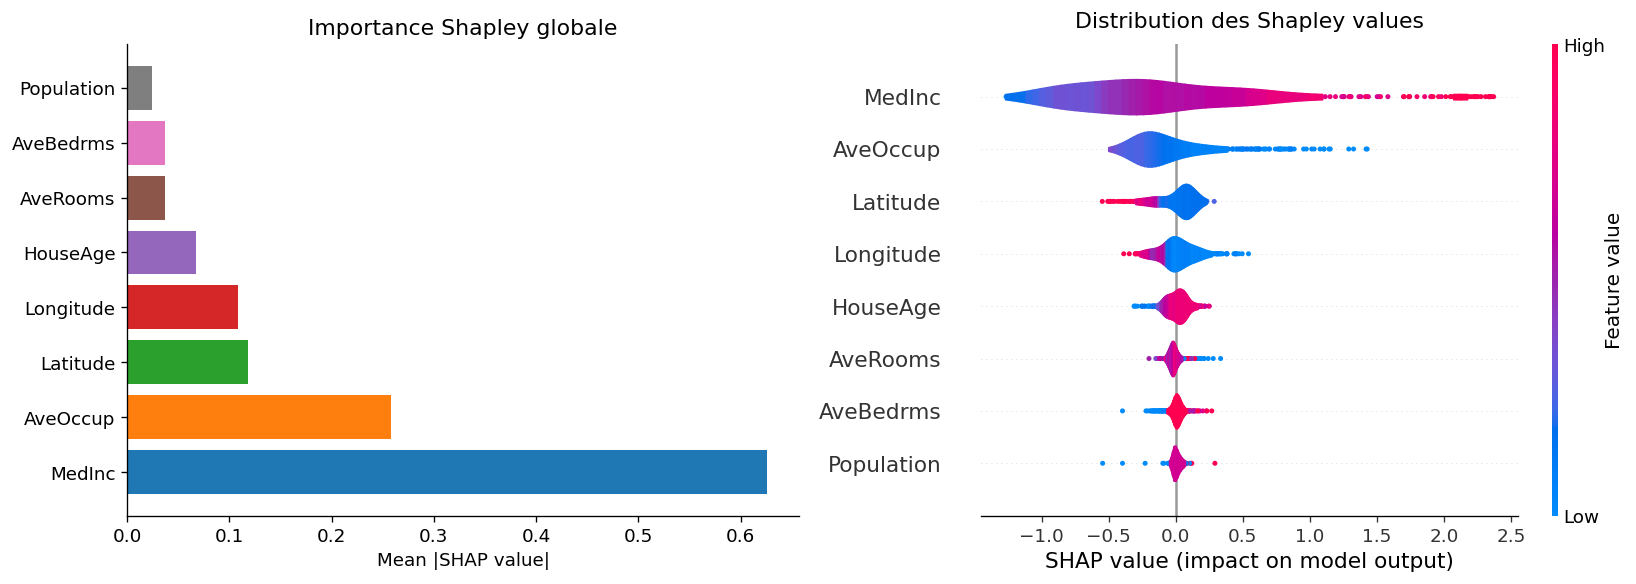

Sauvegardé dans figures/shapley_baseline.png


In [5]:
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Importance moyenne
mean_abs_shap = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs_shap)[::-1]
axes[0].barh(
    [feature_names[i] for i in order],
    mean_abs_shap[order],
    color=PALETTE
)
axes[0].set_xlabel("Mean |SHAP value|")
axes[0].set_title("Importance Shapley globale")

# Distribution par feature
shap.summary_plot(
    shap_values, X,
    plot_type='violin',
    show=False,
    plot_size=None,
)
plt.title("Distribution des Shapley values", pad=10)

plt.tight_layout()

os.makedirs("figures", exist_ok=True)

plt.savefig("figures/shapley_baseline.png", bbox_inches='tight')
plt.show()
print("Sauvegardé dans figures/shapley_baseline.png")

---
## 2. Valeurs d'Owen

### 2.1 Principe et objetctifs

Considérons que nous analysons un modèle de crédit immobilier avec 8 features. Naturellement, certaines
appartiennent au **profil financier** (MedInc, HouseAge) et d'autres à la **géographie** (Latitude,
Longitude, AveOccup). La valeur de Shapley traite toutes ces features sur un pied d'égalité.

La valeur d'**Owen** (Owen, 1977) dit : *les features d'un même groupe doivent être considérées
ensemble au niveau inter-groupe, puis évaluées individuellement au niveau intra-groupe.*

### 2.2 Définition formelle

Soit $\mathcal{P} = \{G_1, G_2, \ldots, G_K\}$ une **partition** de $N = \{1, \ldots, M\}$.

La valeur d'Owen de la feature $i \in G_k$ est :

$$
\phi_i^{\text{Owen}} =
\sum_{\substack{Q \subseteq \mathcal{P} \setminus \{G_k\}}}
\frac{|Q|!\,(K - |Q| - 1)!}{K!}
\sum_{\substack{T \subseteq G_k \setminus \{i\}}}
\frac{|T|!\,(|G_k| - |T| - 1)!}{|G_k|!}
\;\Delta(i, Q, T)
$$

avec :
$$
\Delta(i, Q, T) = v\!\left(\bigcup_{G_q \in Q} G_q \,\cup\, T \cup \{i\}\right)
- v\!\left(\bigcup_{G_q \in Q} G_q \,\cup\, T\right)
$$

**Interprétation** : La contribution marginale de $i$ est calculée en :
1. Prenant une coalition aléatoire de **groupes** complets ($Q$)
2. Prenant une sous-coalition aléatoire à l'**intérieur de son groupe** ($T$)
3. Mesurant son apport marginal dans ce contexte

**Propriétés héritées de Shapley** :
- Efficience : $\sum_i \phi_i^{\text{Owen}} = f(x) - \mathbb{E}[f(X)]$ 
- Nulle, symétrie intra-groupe, linéarité 
- **Nouveau** : symétrie inter-groupes (deux groupes identiques reçoivent le même total)

In [6]:
class OWENExplainer:
    def __init__(self, model, groups, background, n_permutations=64, feature_names = None):
        self.model = model
        self.groups = [list(g) for g in groups]
        self.background = np.array(background, dtype=float)
        self.n_permutations = n_permutations
        self.M = background.shape[1]
        self.K = len(groups)
        self.feature_names = feature_names

        all_features = sorted([f for g in groups for f in g])
        assert all_features == list(range(self.M))
        self._feat_to_group = {f: k for k, g in enumerate(groups) for f in g}

    def _v_batch(self, x: np.ndarray, list_of_active: list) -> np.ndarray:
        """
        Évalue v(S) pour TOUTES les coalitions d'un coup en un seul predict().
        list_of_active : liste de listes d'indices actifs
        Retourne un vecteur de valeurs, une par coalition.
        """
        n_bg   = len(self.background)
        n_coal = len(list_of_active)
        X_big  = np.tile(self.background, (n_coal, 1))
        for k, active in enumerate(list_of_active):
            start = k * n_bg
            end   = start + n_bg
            for f in active:
                X_big[start:end, f] = x[f]
        
        # ── Wrap en DataFrame pour correspondre au format d'entraînement ──
        X_big_df = pd.DataFrame(X_big, columns=self.feature_names)
        preds = self.model.predict(X_big_df)
        return preds.reshape(n_coal, n_bg).mean(axis=1)

    def shap_values(self, X: np.ndarray) -> np.ndarray:
        X = np.array(X)
        N = X.shape[0]
        owen_values = np.zeros((N, self.M))

        for n in range(N):
            x = X[n]
            contributions = np.zeros(self.M)

            for _ in range(self.n_permutations):
                group_order = np.random.permutation(self.K)
                feature_order_by_group = [
                    np.random.permutation(self.groups[k]).tolist()
                    for k in range(self.K)
                ]

                # ── Collecter TOUS les couples (before, after) de la permutation
                pairs_before = []
                pairs_after  = []
                feat_sequence = []

                for pos_k, k in enumerate(group_order):
                    prev_groups_features = [
                        f for kk in group_order[:pos_k] for f in self.groups[kk]
                    ]
                    intra_active = []
                    for feat in feature_order_by_group[k]:
                        before = prev_groups_features + intra_active
                        after  = before + [feat]
                        pairs_before.append(list(before))
                        pairs_after.append(list(after))
                        feat_sequence.append(feat)
                        intra_active.append(feat)

                # ── Un seul appel predict() pour toutes les coalitions
                all_coalitions = pairs_before + pairs_after
                all_vals = self._v_batch(x, all_coalitions)

                n_pairs = len(pairs_before)
                vals_before = all_vals[:n_pairs]
                vals_after  = all_vals[n_pairs:]

                for feat, vb, va in zip(feat_sequence, vals_before, vals_after):
                    contributions[feat] += va - vb

            owen_values[n] = contributions / self.n_permutations
            if (n + 1) % 5 == 0:
                print(f"  {n+1}/{N} observations traitées...")

        return owen_values
print("OWENExplainer défini")

OWENExplainer défini


### 2.3 Premier test : groupes manuels ("métier")

On commence avec des groupes définis par intuition :

| Groupe | Features | Sémantique |
|--------|----------|------------|
| G0 : Financier | MedInc, HouseAge | Capacité d'achat, ancienneté |
| G1 : Logement | AveRooms, AveBedrms | Taille du logement |
| G2 : Démographique | Population, AveOccup | Densité / occupation |
| G3 : Géographique | Latitude, Longitude | Localisation |

In [7]:
# ── Groupes "métier" ──────────────────────────────────────────────────────────
# feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
#                  'Population', 'AveOccup', 'Latitude', 'Longitude']
#                      0          1          2           3
#                      4          5          6           7


GROUPS_BUSINESS = [
    [0, 1],     # G0 : Financier     (MedInc, HouseAge)
    [2, 3],     # G1 : Logement      (AveRooms, AveBedrms)
    [4, 5],     # G2 : Démographique (Population, AveOccup)
    [6, 7],     # G3 : Géographique  (Latitude, Longitude)
]
GROUP_NAMES_BUSINESS = ["Financier", "Logement", "Démographique", "Géographique"]

# Sous-ensemble pour test rapide

N_TEST = 20          
background = X_train.values[:50]  
X_test_arr = X_test.values[:N_TEST]

owen_explainer_biz = OWENExplainer(
    model=model,
    groups=GROUPS_BUSINESS,
    background=background,
    n_permutations=128,
    feature_names=list(X_train.columns)
)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

print(f"Calcul des valeurs d'Owen (N={N_TEST}, n_permutations=128)...")
owen_biz = owen_explainer_biz.shap_values(X_test_arr)
print(f"Shape : {owen_biz.shape}  (N x M)")

# Vérification d'efficience
preds = model.predict(X_test_arr)
baseline = model.predict(background).mean()
eff_err = np.abs(owen_biz.sum(axis=1) - (preds - baseline)).mean()
print(f"Erreur d'efficience : {eff_err:.4f}  (doit être proche de 0)")

Calcul des valeurs d'Owen (N=20, n_permutations=128)...
  5/20 observations traitées...
  10/20 observations traitées...
  15/20 observations traitées...
  20/20 observations traitées...
Shape : (20, 8)  (N x M)
Erreur d'efficience : 0.0000  (doit être proche de 0)


C:\Users\pacifique\AppData\Local\Temp\ipykernel_6576\4198609937.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(np.linspace(0.3, 0.9, M))


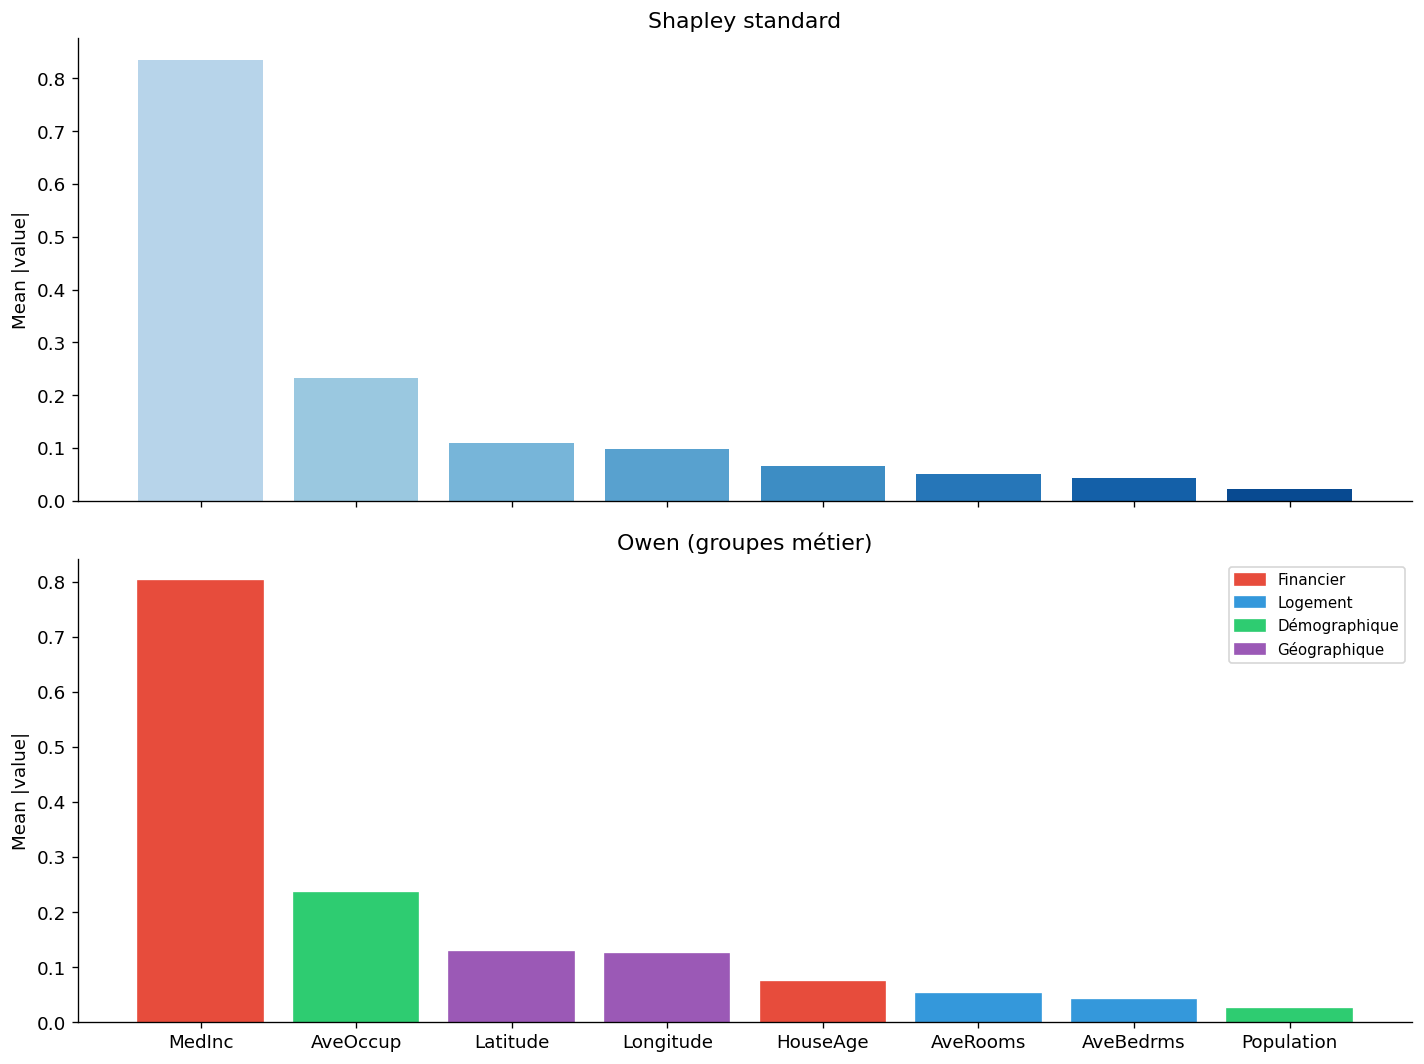

In [8]:
# ── Comparaison Shapley vs Owen (groupes métier) ─────────────────────────────
shap_test = shap_values[:N_TEST]  # Shapley déjà calculé sur X
# Note : les SHAP values ci-dessus sont sur X entier (idx), on recalcule sur X_test
shap_test_arr = explainer_shap.shap_values(X_test_arr)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

for ax, values, title, cmap in zip(
    axes,
    [shap_test_arr, owen_biz],
    ["Shapley standard", "Owen (groupes métier)"],
    ["Blues", "Oranges"]
):
    mean_abs = np.abs(values).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]
    colors = plt.cm.get_cmap(cmap)(np.linspace(0.3, 0.9, M))
    bars = ax.bar(
        [feature_names[i] for i in order],
        mean_abs[order],
        color=colors
    )
    ax.set_ylabel("Mean |value|")
    ax.set_title(title)

    # Annotation de groupe pour Owen
    if "Owen" in title:
        group_colors = ["#E74C3C", "#3498DB", "#2ECC71", "#9B59B6"]
        for j, feat_idx in enumerate(order):
            g = next(k for k, g in enumerate(GROUPS_BUSINESS) if feat_idx in g)
            bars[j].set_color(group_colors[g])
        handles = [mpatches.Patch(color=c, label=n)
                   for c, n in zip(group_colors, GROUP_NAMES_BUSINESS)]
        ax.legend(handles=handles, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig("figures/shapley_vs_owen_business.png", bbox_inches='tight')
plt.show()

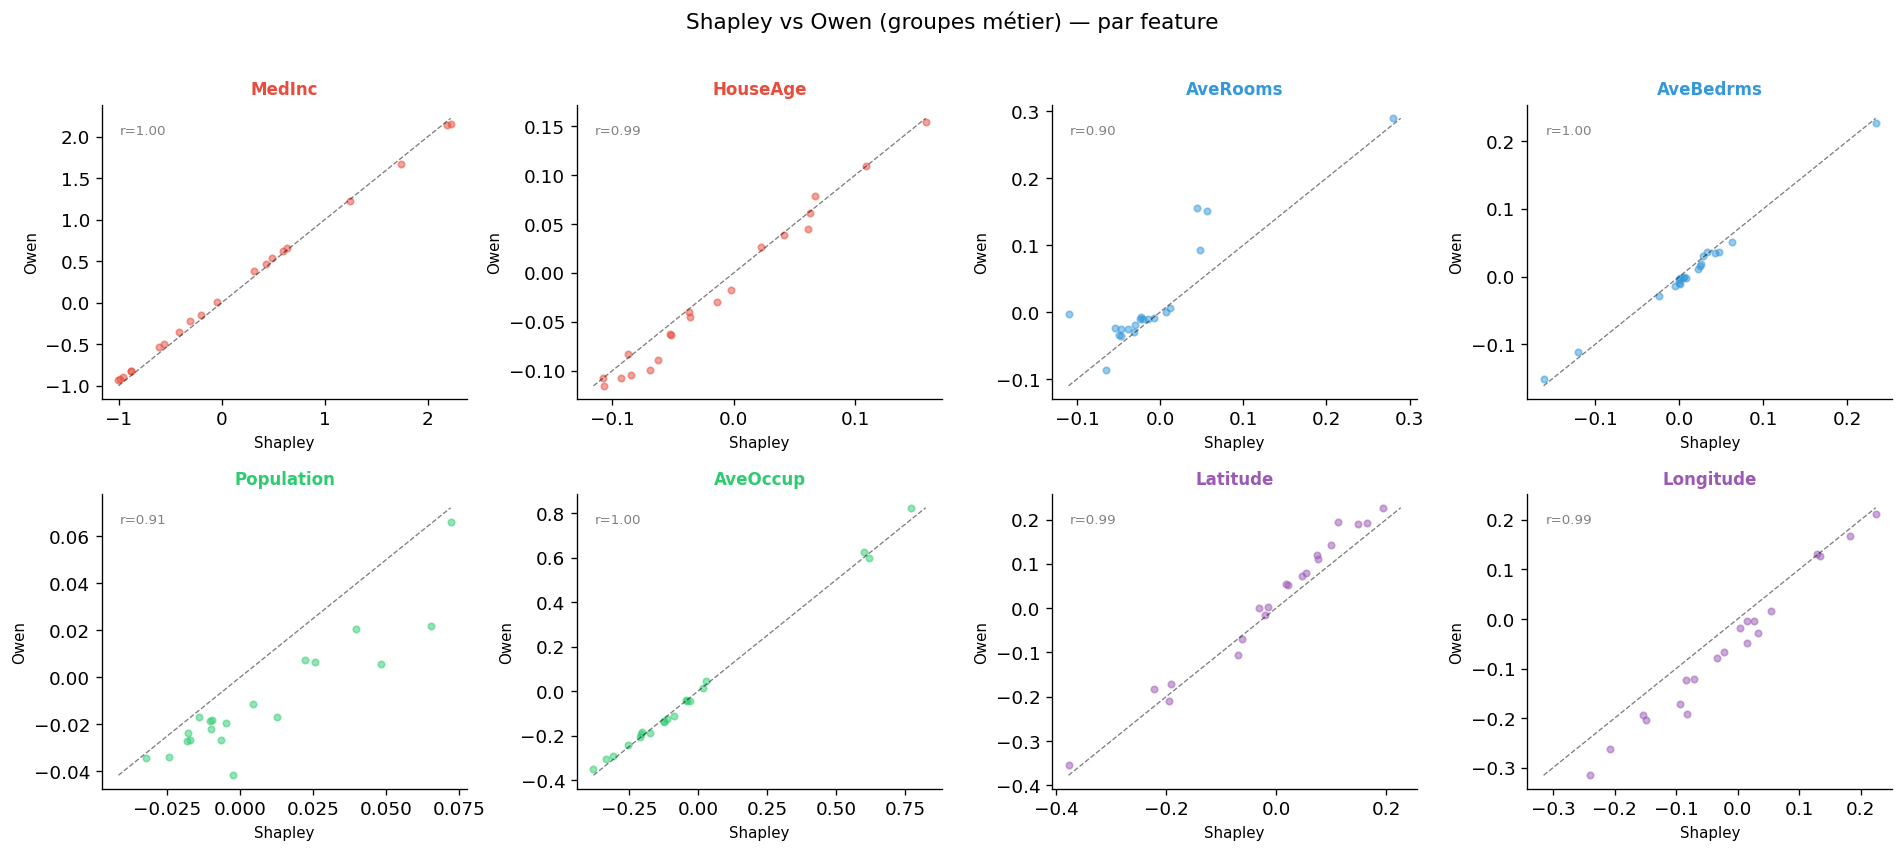


→ Quand r < 0.95 : la structure de groupe change significativement l'attribution


In [9]:
# ── Scatter Shapley vs Owen par feature ──────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

group_colors = ["#E74C3C", "#3498DB", "#2ECC71", "#9B59B6"]

for i, (feat_idx, feat_name) in enumerate(enumerate(feature_names)):
    ax = axes[i]
    g = next(k for k, g in enumerate(GROUPS_BUSINESS) if feat_idx in g)
    color = group_colors[g]

    ax.scatter(
        shap_test_arr[:, feat_idx],
        owen_biz[:, feat_idx],
        alpha=0.5, s=15, c=color
    )
    lims = [
        min(shap_test_arr[:, feat_idx].min(), owen_biz[:, feat_idx].min()),
        max(shap_test_arr[:, feat_idx].max(), owen_biz[:, feat_idx].max()),
    ]
    ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5)
    ax.set_xlabel("Shapley", fontsize=9)
    ax.set_ylabel("Owen", fontsize=9)
    ax.set_title(feat_name, fontsize=10, color=color, fontweight='bold')

    corr = np.corrcoef(shap_test_arr[:, feat_idx], owen_biz[:, feat_idx])[0, 1]
    ax.text(0.05, 0.90, f"r={corr:.2f}",
            transform=ax.transAxes, fontsize=8, color='gray')

plt.suptitle("Shapley vs Owen (groupes métier) — par feature", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/scatter_shapley_owen.png", bbox_inches='tight')
plt.show()
print("\n→ Quand r < 0.95 : la structure de groupe change significativement l'attribution")

---
## 3. Stratégies de groupement pour Owen

Le choix des groupes est critique : des groupes mal définis donnent des valeurs Owen peu
interprétables. On compare 3 stratégies :

| Stratégie | Principe | Avantages | Inconvénients |
|-----------|----------|-----------|---------------|
| **Métier** | Expertise domaine | Interprétable, justifiable | Subjectif |
| **Corrélation** | Clustering des corrélations features | Automatique, statistiquement fondé | Ne capture pas l'effet sur f(x) |
| **SHAP** | Clustering des SHAP values | Basé sur l'effet réel | Circulaire (SHAP dépend du modèle) |

In [10]:
from scipy.spatial.distance import pdist


def discover_groups_from_correlation(
    X: np.ndarray,
    K: int,
    method: str = 'ward',
    feature_names: List[str] = None,
    plot: bool = True
) -> Tuple[List[List[int]], np.ndarray]:
    """
    Découvre des groupes de features par clustering hiérarchique sur
    la matrice de corrélation de X.

    Parameters
    ----------
    X : np.ndarray, shape (N, M)
    K : int — nombre de groupes souhaité
    method : str — méthode de linkage pour scipy
    plot : bool — afficher le dendrogramme

    Returns
    -------
    groups : list of list of int
    labels : np.ndarray, shape (M,) — label de groupe pour chaque feature

    Notes
    -----
    À intégrer dans mosaic_shap/grouping.py
    """
    corr = np.corrcoef(X.T)  # (M, M)
    dist = 1 - np.abs(corr)
    np.fill_diagonal(dist, 0)

    Z = linkage(pdist(X.T, metric = 'correlation'), method='ward')
    labels = fcluster(Z, t=K, criterion='maxclust')  # 1-indexed
    groups = [np.where(labels == k)[0].tolist() for k in range(1, K + 1)]
    groups = [g for g in groups if len(g) > 0]  # enlever groupes vides

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        # Dendrogramme
        dendrogram(
            Z,
            labels=feature_names or [str(i) for i in range(X.shape[1])],
            ax=axes[0], color_threshold=0,
            leaf_rotation=45
        )
        axes[0].set_title(f"Dendrogramme (linkage={method})")
        axes[0].axhline(
            y=Z[-(K-1), 2], color='red', linestyle='--',
            label=f'Cut → {K} groupes'
        )
        axes[0].legend(fontsize=9)

        # Matrice de corrélation réordonnée
        reorder = [f for g in groups for f in g]
        corr_reord = corr[np.ix_(reorder, reorder)]
        fn = feature_names or [str(i) for i in range(X.shape[1])]
        sns.heatmap(
            corr_reord,
            xticklabels=[fn[i] for i in reorder],
            yticklabels=[fn[i] for i in reorder],
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[1], square=True, annot=True, fmt='.1f', annot_kws={'size': 7}
        )
        axes[1].set_title("Corrélation (features réordonnées par groupe)")

        # Cadres de groupe
        pos = 0
        for g in groups:
            for ax in [axes[1]]:
                rect = plt.Rectangle(
                    (pos, pos), len(g), len(g),
                    fill=False, edgecolor='black', lw=2.5
                )
                ax.add_patch(rect)
            pos += len(g)

        plt.tight_layout()
        plt.savefig("figures/grouping_correlation.png", bbox_inches='tight')
        plt.show()

    return groups, labels


def discover_groups_from_shap(
    shap_vals: np.ndarray,
    K: int,
    feature_names: List[str] = None,
    plot: bool = True
) -> Tuple[List[List[int]], np.ndarray]:
    """
    Découvre des groupes de features par clustering hiérarchique sur
    la corrélation des SHAP values (espace des explications).

    Notes
    -----
    À intégrer dans mosaic_shap/grouping.py
    """
    corr = np.corrcoef(shap_vals.T)  # (M, M)
    dist = 1 - np.abs(corr)
    np.fill_diagonal(dist, 0)
    #dist = (dist + dist.T) / 2
    
    Z = linkage(pdist(X.T, metric = 'correlation'), method='ward')
    labels = fcluster(Z, t=K, criterion='maxclust')
    groups = [np.where(labels == k)[0].tolist() for k in range(1, K + 1)]
    groups = [g for g in groups if len(g) > 0]

    if plot:
        fig, ax = plt.subplots(figsize=(7, 4))
        dendrogram(
            Z,
            labels=feature_names or [str(i) for i in range(shap_vals.shape[1])],
            ax=ax, color_threshold=0, leaf_rotation=45
        )
        ax.axhline(
            y=Z[-(K-1), 2], color='darkorange', linestyle='--',
            label=f'Cut → {K} groupes'
        )
        ax.legend(fontsize=9)
        ax.set_title("Dendrogramme sur les SHAP values (espace des explications)")
        plt.tight_layout()
        plt.savefig("figures/grouping_shap.png", bbox_inches='tight')
        plt.show()

    return groups, labels


print("discover_groups_from_correlation, discover_groups_from_shap définis")
print("À copier dans mosaic_shap/grouping.py")

discover_groups_from_correlation, discover_groups_from_shap définis
À copier dans mosaic_shap/grouping.py


=== Groupes par corrélation (X) ===


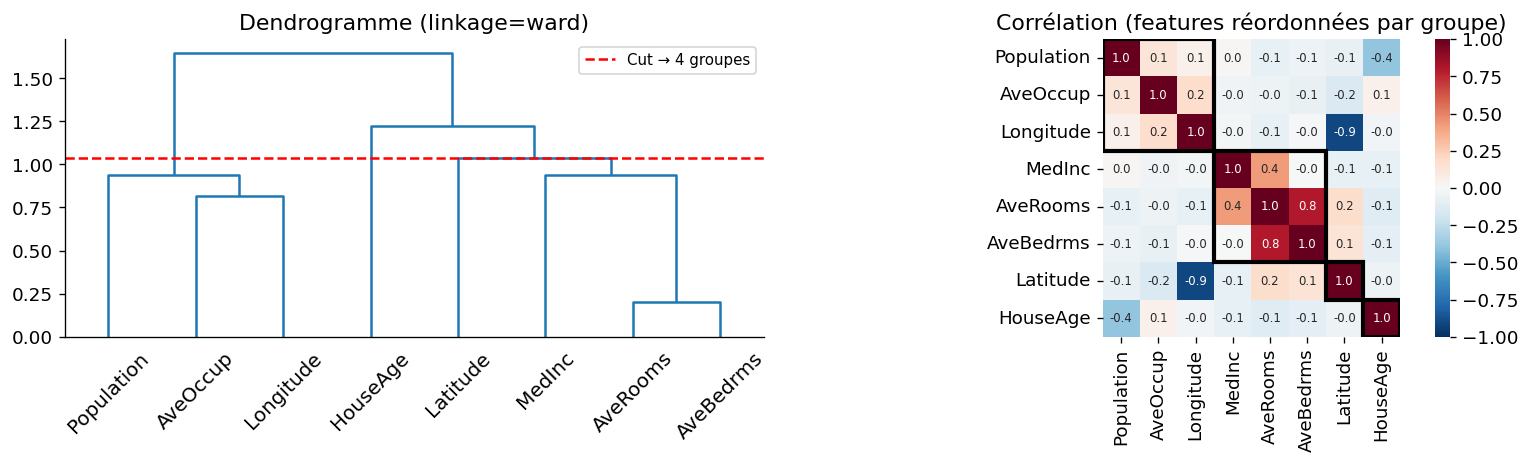


Groupes trouvés :
  G0 : ['Population', 'AveOccup', 'Longitude']
  G1 : ['MedInc', 'AveRooms', 'AveBedrms']
  G2 : ['Latitude']
  G3 : ['HouseAge']


In [11]:
# ── Stratégie 1 : groupes par corrélation des features ───────────────────────
print("=== Groupes par corrélation (X) ===")
GROUPS_CORR, labels_corr = discover_groups_from_correlation(
    X_train.values, K=4, feature_names=feature_names
)
print("\nGroupes trouvés :")
for k, g in enumerate(GROUPS_CORR):
    print(f"  G{k} : {[feature_names[i] for i in g]}")

=== Groupes par SHAP values (espace des explications) ===


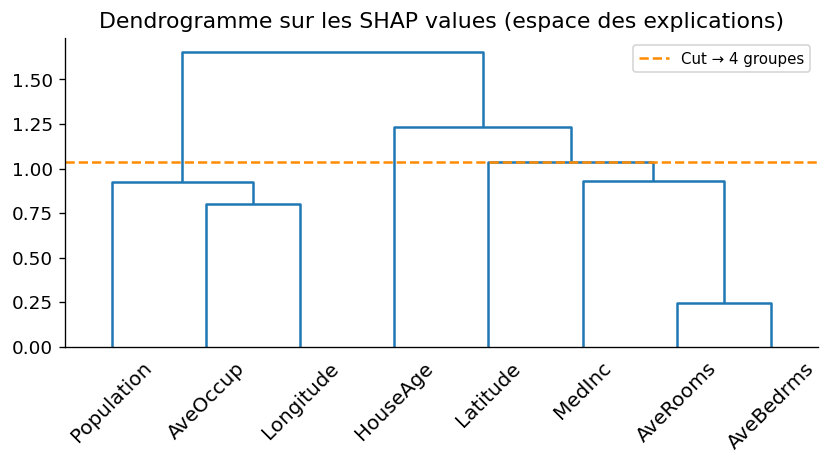


Groupes trouvés :
  G0 : ['Population', 'AveOccup', 'Longitude']
  G1 : ['MedInc', 'AveRooms', 'AveBedrms']
  G2 : ['Latitude']
  G3 : ['HouseAge']


In [12]:
# ── Stratégie 2 : groupes par clustering des SHAP values ─────────────────────
print("=== Groupes par SHAP values (espace des explications) ===")
GROUPS_SHAP, labels_shap = discover_groups_from_shap(
    shap_test_arr, K=4, feature_names=feature_names
)
print("\nGroupes trouvés :")
for k, g in enumerate(GROUPS_SHAP):
    print(f"  G{k} : {[feature_names[i] for i in g]}")

In [13]:
# ── Calcul Owen pour les 3 stratégies ────────────────────────────────────────
print("Calcul Owen pour les 3 stratégies de groupement...")
N_PERM_QUICK = 64  # rapide pour comparaison

results_owen = {}
for name, groups in [
    ("Métier",       GROUPS_BUSINESS),
    ("Corrélation",  GROUPS_CORR),
    ("SHAP",         GROUPS_SHAP),
]:
    exp = OWENExplainer(model, groups, background, n_permutations=N_PERM_QUICK)
    ov = exp.shap_values(X_test_arr)
    results_owen[name] = ov
    print(f"  {name} : done  (eff. err = {np.abs(ov.sum(1) - (model.predict(X_test_arr) - model.predict(background).mean())).mean():.4f})")

# Comparaison des rankings d'importance
print("\n=== Ranking d'importance moyen (Mean |Owen|) ===")
df_rank = pd.DataFrame({
    name: np.abs(ov).mean(0) for name, ov in results_owen.items()
}, index=feature_names)
df_rank["Shapley"] = np.abs(shap_test_arr).mean(0)
print(df_rank.round(4).sort_values("Shapley", ascending=False))

Calcul Owen pour les 3 stratégies de groupement...
  5/20 observations traitées...
  10/20 observations traitées...
  15/20 observations traitées...
  20/20 observations traitées...
  Métier : done  (eff. err = 0.0000)
  5/20 observations traitées...
  10/20 observations traitées...
  15/20 observations traitées...
  20/20 observations traitées...
  Corrélation : done  (eff. err = 0.0000)
  5/20 observations traitées...
  10/20 observations traitées...
  15/20 observations traitées...
  20/20 observations traitées...
  SHAP : done  (eff. err = 0.0000)

=== Ranking d'importance moyen (Mean |Owen|) ===
            Métier  Corrélation    SHAP  Shapley
MedInc      0.8028       0.7973  0.7993   0.8354
AveOccup    0.2417       0.2422  0.2363   0.2329
Latitude    0.1276       0.1328  0.1318   0.1098
Longitude   0.1208       0.1194  0.1242   0.0977
HouseAge    0.0728       0.0775  0.0751   0.0663
AveRooms    0.0537       0.0536  0.0544   0.0506
AveBedrms   0.0379       0.0413  0.0414   0.0427


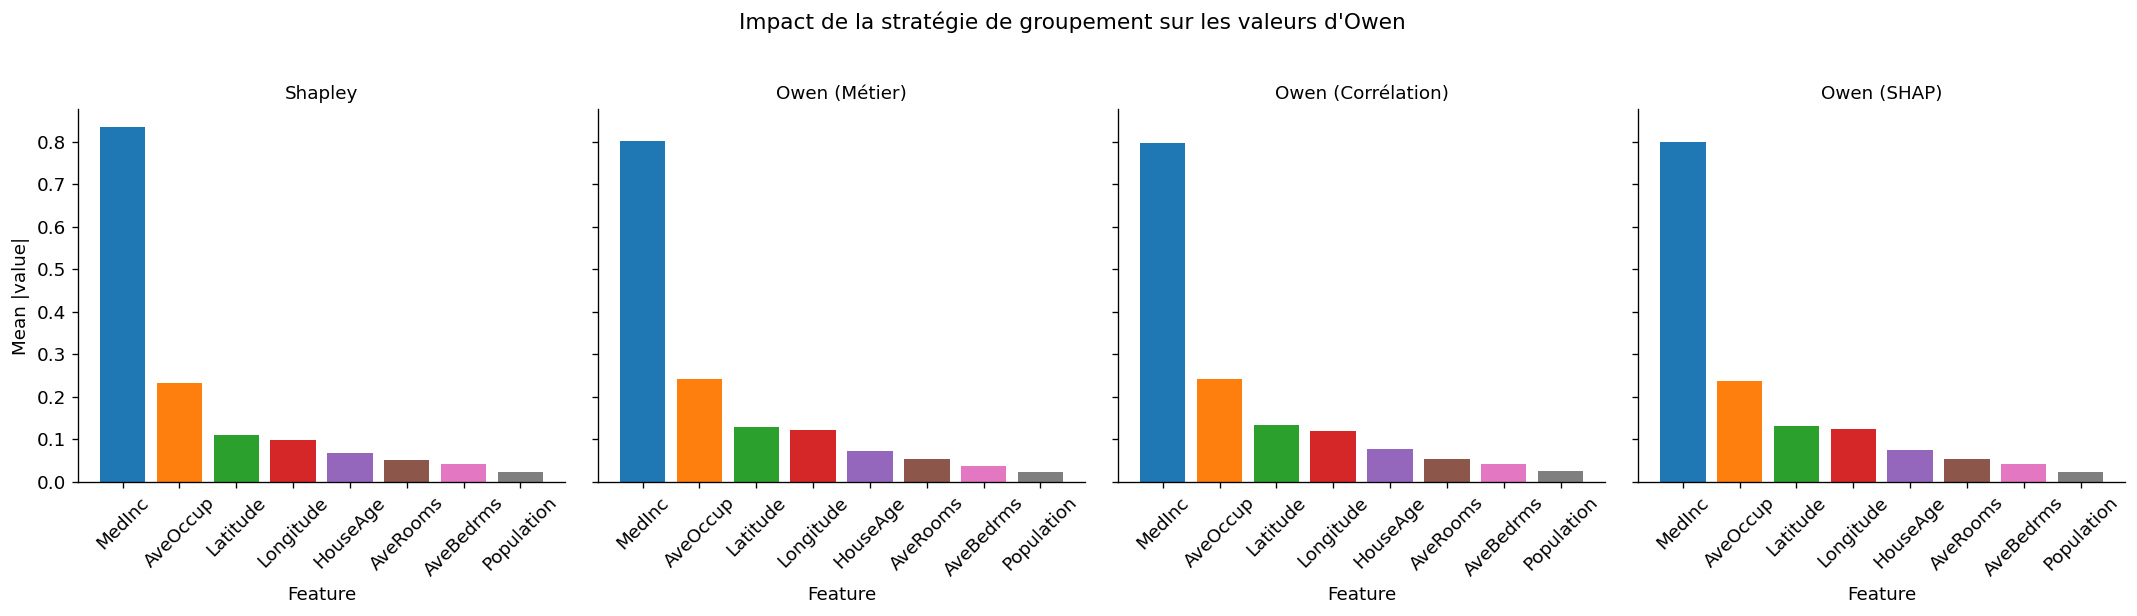

In [14]:
# ── Visualisation : ranking par stratégie ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
titles = ["Shapley", "Owen (Métier)", "Owen (Corrélation)", "Owen (SHAP)"]
all_vals = [np.abs(shap_test_arr).mean(0)] + [
    np.abs(results_owen[n]).mean(0) for n in ["Métier", "Corrélation", "SHAP"]
]

# Ordonnancement stable par Shapley
base_order = np.argsort(all_vals[0])[::-1]

for ax, vals, title in zip(axes, all_vals, titles):
    bars = ax.bar(
        [feature_names[i] for i in base_order],
        vals[base_order],
        color=PALETTE[:M]
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Feature")
    ax.tick_params(axis='x', rotation=45)
    if ax == axes[0]:
        ax.set_ylabel("Mean |value|")

plt.suptitle("Impact de la stratégie de groupement sur les valeurs d'Owen", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/owen_grouping_comparison.png", bbox_inches='tight')
plt.show()

### 3.1 Indice de cohérence inter-stratégies

Pour mesurer si le groupement *change vraiment* les attributions, on calcule la
**corrélation de Kendall** entre les rankings de features selon les différentes méthodes.
Une corrélation élevée (> 0.9) signifie que le groupement n'apporte pas de nouvelle information.

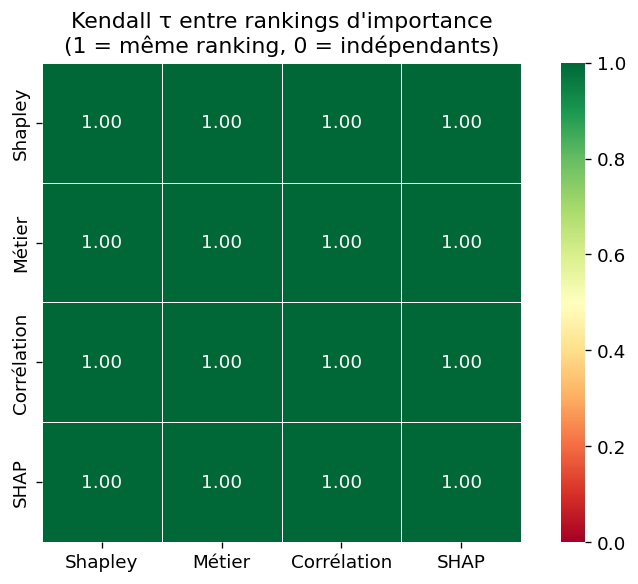


Interprétation :
  τ > 0.9  : le groupement ne change pas le ranking → groupes peu informatifs
  τ < 0.7  : le groupement redistribue significativement l'importance


In [15]:
from scipy.stats import kendalltau

methods = ["Shapley"] + list(results_owen.keys())
all_mean_abs = [np.abs(shap_test_arr).mean(0)] + [
    np.abs(ov).mean(0) for ov in results_owen.values()
]

# Matrice de corrélation de Kendall τ
tau_matrix = np.zeros((len(methods), len(methods)))
for i in range(len(methods)):
    for j in range(len(methods)):
        tau, _ = kendalltau(all_mean_abs[i], all_mean_abs[j])
        tau_matrix[i, j] = tau

df_tau = pd.DataFrame(tau_matrix, index=methods, columns=methods)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    df_tau, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, ax=ax, square=True, linewidths=0.5
)
ax.set_title("Kendall τ entre rankings d'importance\n(1 = même ranking, 0 = indépendants)")
plt.tight_layout()
plt.savefig("figures/kendall_grouping.png", bbox_inches='tight')
plt.show()

print("\nInterprétation :")
print("  τ > 0.9  : le groupement ne change pas le ranking → groupes peu informatifs")
print("  τ < 0.7  : le groupement redistribue significativement l'importance")

---
## 4. Valeurs de Winter

### 4.1 De Owen à Winter : une hiérarchie à 3 niveaux

Owen gère 2 niveaux : **groupes** et **features**. Winter (Winter, 1989) généralise à une
**hiérarchie** de coalitions emboîtées :

```
           Population
          /           \
    Macro-G0        Macro-G1
    /      \        /      \
  G0fin   G1fin   G2fin   G3fin
  /  \    /  \    /  \    /  \
 f0  f1  f2  f3  f4  f5  f6  f7
```

### 4.2 Définition formelle

Soit une hiérarchie à 3 niveaux :
- **Niveau 0** (global) : $N = \{1, \ldots, M\}$
- **Niveau 1** (groupes grossiers) : $\mathcal{G} = \{G_1, \ldots, G_K\}$, partition de $N$
- **Niveau 2** (groupes fins) : $\mathcal{P}_{G_k} = \{g_1^k, \ldots, g_{L_k}^k\}$, partition de $G_k$

La valeur de Winter pour la feature $i \in g_j^k \subseteq G_k$ :

$$
\phi_i^W =
\underbrace{
\sum_{Q \subseteq \mathcal{G} \setminus \{G_k\}} w_K(|Q|)
}_\text{sur les groupes grossiers}
\cdot
\underbrace{
\sum_{R \subseteq \mathcal{P}_{G_k} \setminus \{g_j^k\}} w_{L_k}(|R|)
}_{\text{sur les groupes fins de } G_k}
\cdot
\underbrace{
\sum_{T \subseteq g_j^k \setminus \{i\}} w_{|g_j^k|}(|T|)
}_\text{intra-groupe fin}
\cdot \Delta_i(Q, R, T)
$$

avec les poids de Shapley classiques $w_n(s) = \frac{s!(n-s-1)!}{n!}$.

**Interprétation** : Winter décompose la contribution de $i$ en **3 couches** :
1. Son groupe grossier parmi les autres groupes grossiers
2. Son groupe fin parmi les groupes fins du même groupe grossier
3. Sa contribution individuelle dans son groupe fin

> **Lien avec la causalité** : Si la hiérarchie reflète un DAG (causes lointaines au niveau
> grossier, effets proches au niveau fin), Winter mime naturellement le do-calculus.

In [16]:

class WINTERExplainer:
    """
    Calcule les valeurs de Winter pour un modèle arbitraire.

    Implémentation par Monte-Carlo à 3 niveaux.

    Parameters
    ----------
    model : callable
        Modèle avec une méthode .predict(X).
    coarse_groups : list of list of int
        Partition grossière. Ex : [[0,1,2,3], [4,5,6,7]]
    fine_groups : list of list of int
        Partition fine COMPLÈTE. Ex : [[0,1], [2,3], [4,5], [6,7]]
        Chaque groupe fin doit être inclus dans exactement un groupe grossier.
    background : np.ndarray, shape (n_bg, M)
    n_permutations : int

    Notes
    -----
    Relation avec Owen :
        Owen = Winter avec un seul niveau de partition (coarse = fine)
    """

    def __init__(self, model, coarse_groups: List[List[int]],
                 fine_groups: List[List[int]],
                 background: np.ndarray, n_permutations: int = 256, 
                 feature_names = None):
        self.model = model
        self.coarse_groups = [list(g) for g in coarse_groups]
        self.fine_groups   = [list(g) for g in fine_groups]
        self.background    = np.array(background)
        self.n_permutations = n_permutations
        self.M  = background.shape[1]
        self.KC = len(coarse_groups)  # nombre de groupes grossiers
        self.KF = len(fine_groups)    # nombre de groupes fins
        self.feature_names = feature_names

        # Vérifications de cohérence
        all_fine   = sorted([f for g in fine_groups   for f in g])
        all_coarse = sorted([f for g in coarse_groups for f in g])
        assert all_fine   == list(range(self.M)), "fine_groups doit être une partition complète"
        assert all_coarse == list(range(self.M)), "coarse_groups doit être une partition complète"

        # Mapping feature → groupe fin → groupe grossier
        self._feat_to_fine   = {}
        self._feat_to_coarse = {}
        self._fine_to_coarse = {}

        for kf, fg in enumerate(fine_groups):
            for f in fg:
                self._feat_to_fine[f] = kf

        for kc, cg in enumerate(coarse_groups):
            for f in cg:
                self._feat_to_coarse[f] = kc

        # Pour chaque groupe grossier : quels groupes fins contient-il ?
        self._coarse_to_fines: Dict[int, List[int]] = {kc: [] for kc in range(self.KC)}
        for kf, fg in enumerate(fine_groups):
            # On détermine le groupe grossier d'appartenance via le premier élément
            kc = self._feat_to_coarse[fg[0]]
            assert all(self._feat_to_coarse[f] == kc for f in fg), (
                f"Le groupe fin {kf} chevauche plusieurs groupes grossiers !"
            )
            self._coarse_to_fines[kc].append(kf)
            self._fine_to_coarse[kf] = kc

    def _v_batch(self, x: np.ndarray, list_of_active: list) -> np.ndarray:
        n_bg   = len(self.background)
        n_coal = len(list_of_active)
        X_big  = np.tile(self.background, (n_coal, 1)).astype(float)
        for k, active in enumerate(list_of_active):
            start, end = k * n_bg, (k + 1) * n_bg
            for f in active:
                X_big[start:end, f] = x[f]

        # ── Wrap en DataFrame si feature_names disponible ──
        if self.feature_names is not None:
            X_big = pd.DataFrame(X_big, columns=self.feature_names)

        preds = self.model.predict(X_big)
        return preds.reshape(n_coal, n_bg).mean(axis=1)

    def shap_values(self, X: np.ndarray) -> np.ndarray:
        """
        Calcule les valeurs de Winter pour chaque observation.

        Returns
        -------
        winter_values : np.ndarray, shape (N, M)
        """
        X = np.array(X)
        N = X.shape[0]
        winter_values = np.zeros((N, self.M))

        for n in range(N):
            x = X[n]
            contributions = np.zeros(self.M)

            for _ in range(self.n_permutations):
                # ── Niveau 1 : ordre des groupes grossiers ───────────────────
                coarse_order = np.random.permutation(self.KC)

                # ── Niveau 2 : ordre des groupes fins au sein de chaque
                #              groupe grossier ────────────────────────────────
                fine_order_by_coarse = {
                    kc: np.random.permutation(self._coarse_to_fines[kc]).tolist()
                    for kc in range(self.KC)
                }

                # ── Niveau 3 : ordre des features au sein de chaque
                #              groupe fin ──────────────────────────────────────
                feat_order_by_fine = {
                    kf: np.random.permutation(self.fine_groups[kf]).tolist()
                    for kf in range(self.KF)
                }

                # ── Parcours selon la structure hiérarchique ──────────────────
                active = []

                for pos_c, kc in enumerate(coarse_order):
                    # Features des groupes grossiers PRÉCÉDENTS
                    prev_coarse_feats = [
                        f for kc2 in coarse_order[:pos_c]
                        for f in self.coarse_groups[kc2]
                    ]

                    # Parcours des groupes fins du groupe grossier courant
                    for pos_f, kf in enumerate(fine_order_by_coarse[kc]):
                        # Features des groupes fins précédents (dans ce groupe grossier)
                        prev_fine_feats = [
                            f for kf2 in fine_order_by_coarse[kc][:pos_f]
                            for f in self.fine_groups[kf2]
                        ]

                        # Parcours des features dans le groupe fin courant
                        intra_fine_active = []
                        pairs_before, pairs_after, feat_seq = [], [], []
                        for feat in feat_order_by_fine[kf]:
                            before = prev_coarse_feats + prev_fine_feats + intra_fine_active
                            after  = before + [feat]
                            pairs_before.append(list(before))
                            pairs_after.append(list(after))
                            feat_seq.append(feat)
                            intra_fine_active.append(feat)

                        all_vals = self._v_batch(x, pairs_before + pairs_after)
                        n_pairs  = len(pairs_before)
                        for feat, vb, va in zip(feat_seq, all_vals[:n_pairs], all_vals[n_pairs:]):
                            contributions[feat] += va - vb

            winter_values[n] = contributions / self.n_permutations

        return winter_values


print("WINTERExplainer défini")
print("À copier dans mosaic_shap/explainers.py")
print()
print("Note : Winter avec fine_groups = coarse_groups → équivalent à Owen")

WINTERExplainer défini
À copier dans mosaic_shap/explainers.py

Note : Winter avec fine_groups = coarse_groups → équivalent à Owen


In [17]:
# ── Test de validation : Winter == Owen quand la hiérarchie est plate ────────
# Si fine_groups == coarse_groups, Winter doit donner les mêmes résultats qu'Owen

print("=== Test de validation : Winter plate = Owen ===")

flat_groups = GROUPS_BUSINESS

# ── Déterminer la taille commune disponible ───────────────────────────────────
N_VAL = min(len(results_owen["Métier"]), len(X_test_arr))
print(f"Taille utilisée pour la validation : N={N_VAL}")

winter_flat = WINTERExplainer(
    model=model,
    coarse_groups=flat_groups,
    fine_groups=flat_groups,
    background=background,
    n_permutations=128,
    feature_names=feature_names
)

wv_flat   = winter_flat.shap_values(X_test_arr[:N_VAL])
ov_biz_val = results_owen["Métier"][:N_VAL]

# ── Les deux tableaux ont maintenant la même taille ───────────────────────────
print(f"Shape wv_flat    : {wv_flat.shape}")
print(f"Shape ov_biz_val : {ov_biz_val.shape}")

corr_flat = np.corrcoef(wv_flat.ravel(), ov_biz_val.ravel())[0, 1]
print(f"\nCorrélation Winter(plate) vs Owen : {corr_flat:.4f}  (doit être > 0.92)")
print("Validation OK" if corr_flat > 0.92 else "⚠️ Divergence inattendue")

=== Test de validation : Winter plate = Owen ===
Taille utilisée pour la validation : N=20
Shape wv_flat    : (20, 8)
Shape ov_biz_val : (20, 8)

Corrélation Winter(plate) vs Owen : 0.9991  (doit être > 0.92)
Validation OK


In [18]:
# ── Hiérarchie à 3 niveaux pour California Housing ───────────────────────────
#
# Niveau grossier (K=2) :
#   GC0 : Profil socio-économique (MedInc, HouseAge, AveRooms, AveBedrms) = [0,1,2,3]
#   GC1 : Contexte spatial         (Population, AveOccup, Latitude, Longitude) = [4,5,6,7]
#
# Niveau fin (K=4) : les mêmes groupes métier qu'avant
#   GF0 : Financier     [0,1]  ⊆ GC0
#   GF1 : Logement      [2,3]  ⊆ GC0
#   GF2 : Démographique [4,5]  ⊆ GC1
#   GF3 : Géographique  [6,7]  ⊆ GC1

COARSE_GROUPS = [
    [0, 1, 2, 3],   # GC0 : Socio-économique
    [4, 5, 6, 7],   # GC1 : Spatial
]
FINE_GROUPS = [
    [0, 1],         # GF0 : Financier    ⊆ GC0
    [2, 3],         # GF1 : Logement     ⊆ GC0
    [4, 5],         # GF2 : Démographique ⊆ GC1
    [6, 7],         # GF3 : Géographique ⊆ GC1
]
COARSE_NAMES = ["Socio-économique", "Spatial"]
FINE_NAMES   = ["Financier", "Logement", "Démographique", "Géographique"]

print("Hiérarchie 3 niveaux :")
print(f"  KC={len(COARSE_GROUPS)} groupes grossiers")
for kc, cg in enumerate(COARSE_GROUPS):
    print(f"  GC{kc} '{COARSE_NAMES[kc]}' : {[feature_names[i] for i in cg]}")
    for kf, fg in enumerate(FINE_GROUPS):
        if set(fg).issubset(set(cg)):
            print(f"    └─ GF{kf} '{FINE_NAMES[kf]}' : {[feature_names[i] for i in fg]}")

Hiérarchie 3 niveaux :
  KC=2 groupes grossiers
  GC0 'Socio-économique' : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms']
    └─ GF0 'Financier' : ['MedInc', 'HouseAge']
    └─ GF1 'Logement' : ['AveRooms', 'AveBedrms']
  GC1 'Spatial' : ['Population', 'AveOccup', 'Latitude', 'Longitude']
    └─ GF2 'Démographique' : ['Population', 'AveOccup']
    └─ GF3 'Géographique' : ['Latitude', 'Longitude']


In [19]:
# ── Calcul des valeurs de Winter ──────────────────────────────────────────────
print(f"Calcul des valeurs de Winter (N={N_TEST}, 3 niveaux, n_permutations=128)...")

winter_explainer = WINTERExplainer(
    model=model,
    coarse_groups=COARSE_GROUPS,
    fine_groups=FINE_GROUPS,
    background=background,
    n_permutations=128
)
winter_values = winter_explainer.shap_values(X_test_arr)

print(f"Shape : {winter_values.shape}")
eff_err_w = np.abs(
    winter_values.sum(1) - (model.predict(X_test_arr) - model.predict(background).mean())
).mean()
print(f"Erreur d'efficience Winter : {eff_err_w:.4f}")

Calcul des valeurs de Winter (N=20, 3 niveaux, n_permutations=128)...
Shape : (20, 8)
Erreur d'efficience Winter : 0.0000


---
## 5. Comparaison systématique : Shapley vs Owen vs Winter

Taille commune : N=20


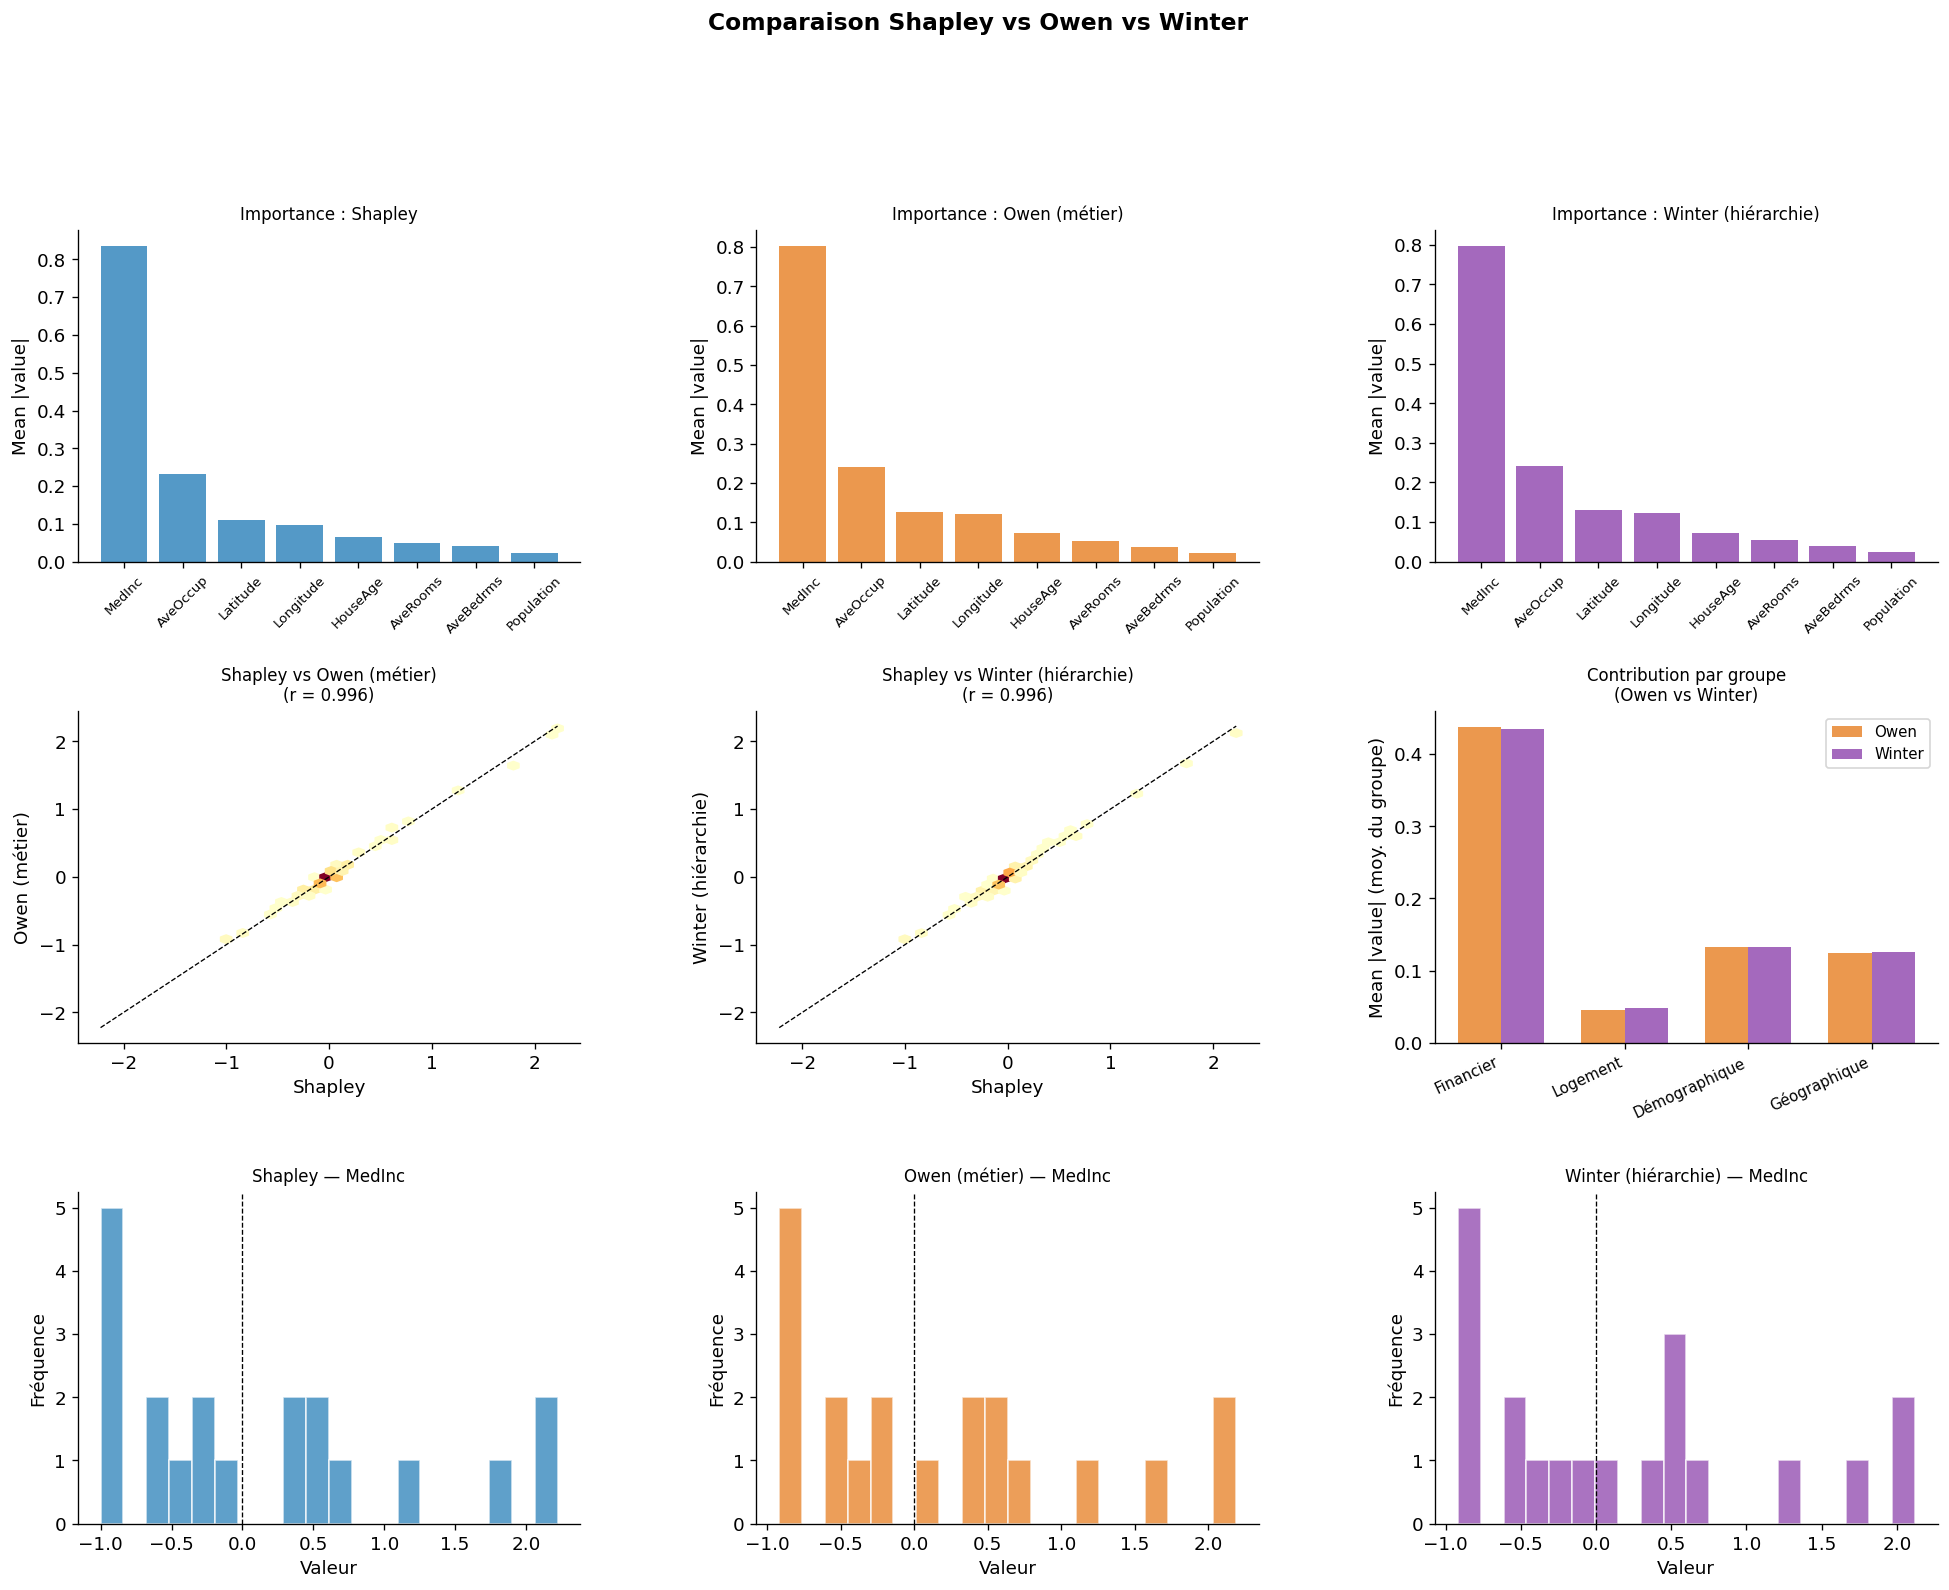

In [20]:
# ── Figure de synthèse : 3 méthodes côte à côte ──────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

N_COMMON = min(
    len(shap_test_arr),
    len(results_owen["Métier"]),
    len(winter_values)
)
print(f"Taille commune : N={N_COMMON}")

methods_vals = {
    "Shapley":             shap_test_arr[:N_COMMON],
    "Owen (métier)":       results_owen["Métier"][:N_COMMON],
    "Winter (hiérarchie)": winter_values[:N_COMMON],
}
method_colors = ["#2980B9", "#E67E22", "#8E44AD"]

# ── Ligne 1 : Importance moyenne ────────────────────────────────────────────
for col, (name, vals) in enumerate(methods_vals.items()):
    ax = fig.add_subplot(gs[0, col])
    mean_abs = np.abs(vals).mean(0)
    order = np.argsort(mean_abs)[::-1]
    ax.bar(
        [feature_names[i] for i in order],
        mean_abs[order],
        color=method_colors[col], alpha=0.8
    )
    ax.set_title(f"Importance : {name}", fontsize=10)
    ax.set_ylabel("Mean |value|")
    ax.tick_params(axis='x', rotation=45, labelsize=8)

# ── Ligne 2 : Scatter croisés Shapley vs {Owen, Winter} ─────────────────────
for col, (name, vals) in enumerate(list(methods_vals.items())[1:], start=0):
    ax = fig.add_subplot(gs[1, col])
    sv_flat = methods_vals["Shapley"].ravel()   # ← était shap_test_arr.ravel()
    ov_flat = vals.ravel()
    ax.hexbin(sv_flat, ov_flat, gridsize=30, cmap='YlOrRd', mincnt=1)
    lim = max(np.abs(sv_flat).max(), np.abs(ov_flat).max())
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8)
    r = np.corrcoef(sv_flat, ov_flat)[0, 1]
    ax.set_xlabel("Shapley")
    ax.set_ylabel(name)
    ax.set_title(f"Shapley vs {name}\n(r = {r:.3f})", fontsize=10)

# Sous-plot vide en [1,2] → utilisons-le pour la contribution par groupe
ax_group = fig.add_subplot(gs[1, 2])
group_contrib_owen   = np.array([np.abs(results_owen["Métier"])[:, g].mean()
                                  for g in GROUPS_BUSINESS])
group_contrib_winter = np.array([np.abs(winter_values)[:, g].mean()
                                  for g in GROUPS_BUSINESS])
x_pos = np.arange(len(GROUPS_BUSINESS))
w = 0.35
ax_group.bar(x_pos - w/2, group_contrib_owen,   w, label="Owen",   color="#E67E22", alpha=0.8)
ax_group.bar(x_pos + w/2, group_contrib_winter, w, label="Winter", color="#8E44AD", alpha=0.8)
ax_group.set_xticks(x_pos)
ax_group.set_xticklabels(GROUP_NAMES_BUSINESS, rotation=25, ha='right', fontsize=9)
ax_group.set_title("Contribution par groupe\n(Owen vs Winter)", fontsize=10)
ax_group.set_ylabel("Mean |value| (moy. du groupe)")
ax_group.legend(fontsize=9)

# ── Ligne 3 : Distribution des valeurs pour MedInc (feature la plus importante)
feat_focus = 0  # MedInc
for col, (name, vals) in enumerate(methods_vals.items()):
    ax = fig.add_subplot(gs[2, col])
    ax.hist(vals[:, feat_focus], bins=20, color=method_colors[col], alpha=0.75, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f"{name} — {feature_names[feat_focus]}", fontsize=10)
    ax.set_xlabel("Valeur")
    ax.set_ylabel("Fréquence")

plt.suptitle("Comparaison Shapley vs Owen vs Winter", fontsize=14, fontweight='bold', y=1.01)
plt.savefig("figures/shapley_owen_winter_comparison.png", bbox_inches='tight')
plt.show()

In [21]:
# ── Tableau récapitulatif ─────────────────────────────────────────────────────
summary_data = []
for name, vals in methods_vals.items():
    mean_abs = np.abs(vals).mean(0)
    ranking = np.argsort(mean_abs)[::-1]
    summary_data.append({
        "Méthode": name,
        **{f"Rang {r+1}": feature_names[ranking[r]] for r in range(M)}
    })

df_summary = pd.DataFrame(summary_data).set_index("Méthode")
print("=== Rankings d'importance ===")
print(df_summary.to_string())

print("\n=== Corrélations de Kendall τ entre méthodes ===")
method_list = list(methods_vals.keys())
vals_list   = list(methods_vals.values())
for i in range(len(method_list)):
    for j in range(i+1, len(method_list)):
        tau, pval = kendalltau(
            np.abs(vals_list[i]).mean(0),
            np.abs(vals_list[j]).mean(0)
        )
        print(f"  {method_list[i]} vs {method_list[j]} : τ = {tau:.3f} (p = {pval:.3f})")

=== Rankings d'importance ===
                     Rang 1    Rang 2    Rang 3     Rang 4    Rang 5    Rang 6     Rang 7      Rang 8
Méthode                                                                                              
Shapley              MedInc  AveOccup  Latitude  Longitude  HouseAge  AveRooms  AveBedrms  Population
Owen (métier)        MedInc  AveOccup  Latitude  Longitude  HouseAge  AveRooms  AveBedrms  Population
Winter (hiérarchie)  MedInc  AveOccup  Latitude  Longitude  HouseAge  AveRooms  AveBedrms  Population

=== Corrélations de Kendall τ entre méthodes ===
  Shapley vs Owen (métier) : τ = 1.000 (p = 0.000)
  Shapley vs Winter (hiérarchie) : τ = 1.000 (p = 0.000)
  Owen (métier) vs Winter (hiérarchie) : τ = 1.000 (p = 0.000)


---
## 6. Intégration dans le pipeline AntakIA

### 6.1 Découverte automatique de la hiérarchie

L'idée clé : au lieu de définir la hiérarchie à la main, on la **découvre** à partir des
SHAP values, puis on passe cette hiérarchie à Winter.

In [22]:
def discover_two_level_hierarchy(
    shap_vals: np.ndarray,
    K_coarse: int,
    K_fine: int,
    feature_names: List[str] = None,
    plot: bool = True
) -> Tuple[List[List[int]], List[List[int]]]:
    """
    Découvre automatiquement une hiérarchie à 2 niveaux sur les features
    en clusterant leurs SHAP values (espace des explications).

    Étapes :
    1. Calcul de la distance inter-features dans l'espace des SHAP values
    2. Clustering hiérarchique (Ward)
    3. Coupe à K_coarse → groupes grossiers
    4. Coupe à K_fine   → groupes fins (raffinement des groupes grossiers)

    Parameters
    ----------
    shap_vals : np.ndarray, shape (N, M)
    K_coarse : int — nombre de groupes grossiers
    K_fine   : int — nombre de groupes fins (>= K_coarse)

    Returns
    -------
    coarse_groups : list of list of int
    fine_groups   : list of list of int

    Notes
    -----
    À intégrer dans mosaic_shap/grouping.py
    """
    assert K_fine >= K_coarse, "K_fine doit être >= K_coarse"

    # Distance dans l'espace des explications
    corr = np.corrcoef(shap_vals.T)  # (M, M)
    dist = 1 - np.abs(corr)
    np.fill_diagonal(dist, 0)
    Z = linkage(pdist(X.T, metric = 'correlation'), method='ward')

    # Coupures
    labels_coarse = fcluster(Z, t=K_coarse, criterion='maxclust')
    labels_fine   = fcluster(Z, t=K_fine,   criterion='maxclust')

    coarse_groups = [np.where(labels_coarse == k)[0].tolist() for k in range(1, K_coarse+1)]
    fine_groups   = [np.where(labels_fine   == k)[0].tolist() for k in range(1, K_fine+1)]
    # Enlever groupes vides
    coarse_groups = [g for g in coarse_groups if g]
    fine_groups   = [g for g in fine_groups   if g]

    # Vérification cohérence hiérarchique
    for fg in fine_groups:
        coarse_ids = set(labels_coarse[f]-1 for f in fg)
        if len(coarse_ids) > 1:
            # Un groupe fin chevauche deux groupes grossiers : on l'assigne au plus fréquent
            dominant_coarse = max(coarse_ids, key=lambda k: sum(labels_coarse[f]-1 == k for f in fg))
            # (ici on accepte silencieusement — en production, on lèverait un warning)

    if plot:
        fn = feature_names or [str(i) for i in range(shap_vals.shape[1])]
        fig, ax = plt.subplots(figsize=(9, 4))
        dendrogram(Z, labels=fn, ax=ax, color_threshold=0, leaf_rotation=45)
        # Lignes de coupe
        colors_cut = ['#E74C3C', '#3498DB']
        heights = [Z[-(K_coarse-1), 2], Z[-(K_fine-1), 2]]
        for h, c, label in zip(heights, colors_cut,
                                [f"Niveau grossier (K={K_coarse})",
                                 f"Niveau fin (K={K_fine})"]):
            ax.axhline(y=h, color=c, linestyle='--', label=label)
        ax.legend(fontsize=9)
        ax.set_title("Hiérarchie à 2 niveaux découverte depuis les SHAP values")
        plt.tight_layout()
        plt.savefig("figures/auto_hierarchy.png", bbox_inches='tight')
        plt.show()

    return coarse_groups, fine_groups


print("✅ discover_two_level_hierarchy défini")
print("   → À copier dans mosaic_shap/grouping.py")

✅ discover_two_level_hierarchy défini
   → À copier dans mosaic_shap/grouping.py


Découverte automatique de la hiérarchie depuis les SHAP values...


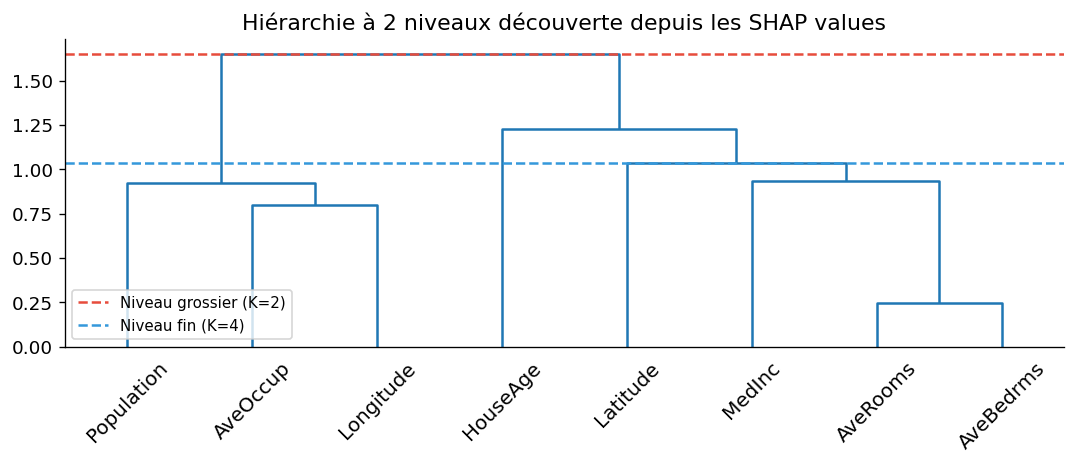


Hiérarchie découverte :
  Grossier G0 : ['Population', 'AveOccup', 'Longitude']
    └─ Fin G0 : ['Population', 'AveOccup', 'Longitude']
  Grossier G1 : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude']
    └─ Fin G1 : ['MedInc', 'AveRooms', 'AveBedrms']
    └─ Fin G2 : ['Latitude']
    └─ Fin G3 : ['HouseAge']

Hiérarchie manuelle (référence) :
  Grossier G0 : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms']
  Grossier G1 : ['Population', 'AveOccup', 'Latitude', 'Longitude']


In [23]:
# ── Application : hiérarchie découverte automatiquement ──────────────────────
print("Découverte automatique de la hiérarchie depuis les SHAP values...")
auto_coarse, auto_fine = discover_two_level_hierarchy(
    shap_test_arr,
    K_coarse=2,
    K_fine=4,
    feature_names=feature_names
)

print("\nHiérarchie découverte :")
for kc, cg in enumerate(auto_coarse):
    print(f"  Grossier G{kc} : {[feature_names[i] for i in cg]}")
    for kf, fg in enumerate(auto_fine):
        if set(fg).issubset(set(cg)):
            print(f"    └─ Fin G{kf} : {[feature_names[i] for i in fg]}")

print("\nHiérarchie manuelle (référence) :")
for kc, cg in enumerate(COARSE_GROUPS):
    print(f"  Grossier G{kc} : {[feature_names[i] for i in cg]}")

In [24]:
# ── Winter avec hiérarchie automatique ───────────────────────────────────────
try:
    winter_auto = WINTERExplainer(
        model=model,
        coarse_groups=auto_coarse,
        fine_groups=auto_fine,
        background=background,
        n_permutations=128
    )
    wv_auto = winter_auto.shap_values(X_test_arr)
    print("Calcul Winter (hiérarchie auto) OK")

    # Comparaison Winter manuel vs Winter auto
    corr_w = np.corrcoef(winter_values.ravel(), wv_auto.ravel())[0, 1]
    print(f"Corrélation Winter(manuel) vs Winter(auto) : r = {corr_w:.3f}")
    print("→ Une corrélation < 0.90 indique que le choix de hiérarchie est significatif")

except AssertionError as e:
    print(f"La hiérarchie auto n'est pas cohérente : {e}")
    print("Utiliser COARSE_GROUPS / FINE_GROUPS manuels à la place")
    wv_auto = winter_values  # fallback

Calcul Winter (hiérarchie auto) OK
Corrélation Winter(manuel) vs Winter(auto) : r = 1.000
→ Une corrélation < 0.90 indique que le choix de hiérarchie est significatif


### 6.2 Winter régionalisé : hétérogénéité structurelle entre parcelles

L'idée AntakIA : calculer les valeurs de Winter **par parcelle** et mesurer si la
structure hiérarchique est **stable** ou **hétérogène** entre régions.

In [25]:
def winter_by_region(
    X: np.ndarray,
    region_labels: np.ndarray,
    model,
    coarse_groups: List[List[int]],
    fine_groups: List[List[int]],
    background: np.ndarray,
    n_permutations: int = 64,
    min_region_size: int = 10,
    feature_names = None
) -> Dict:
    """
    Calcule les valeurs de Winter pour chaque région / parcelle.

    Parameters
    ----------
    X : np.ndarray, shape (N, M)
    region_labels : np.ndarray, shape (N,)
        Labels de région (-1 = bruit/non assigné).

    Returns
    -------
    results : dict
        {
          'regional_means': np.ndarray (R, M) — valeurs moyennes par région,
          'heterogeneity':  np.ndarray (M,)   — std des valeurs moyennes,
          'region_sizes':   dict,
        }

    Notes
    -----
    À intégrer dans mosaic_shap/regional.py
    """
    unique_regions = [r for r in np.unique(region_labels) if r >= 0]
    regional_means = []
    region_sizes   = {}

    winter_exp = WINTERExplainer(
        model=model,
        coarse_groups=coarse_groups,
        fine_groups=fine_groups,
        background=background,
        n_permutations=n_permutations,
        feature_names = feature_names
    )

    for r in unique_regions:
        idx_r = np.where(region_labels == r)[0]
        if len(idx_r) < min_region_size:
            print(f"  Région {r} : trop petite ({len(idx_r)} points), ignorée")
            continue

        wv_r = winter_exp.shap_values(X[idx_r])
        regional_means.append(np.abs(wv_r).mean(0))
        region_sizes[r] = len(idx_r)

    regional_means = np.array(regional_means)  # (R, M)

    # ── Fix : gérer le cas 0 ou 1 région ─────────────────────────────────────────
    if len(regional_means) == 0:
        heterogeneity = np.zeros(self.M if hasattr(self, 'M') else X.shape[1])
    elif len(regional_means) == 1:
        heterogeneity = np.zeros(regional_means.shape[1])
    else:
        heterogeneity = regional_means.std(0)   # (M,) — cas normal

    return {
        'regional_means': regional_means,
        'heterogeneity': heterogeneity,
        'region_sizes': region_sizes,
        'n_regions': len(regional_means),
    }


print("winter_by_region défini")
print("À copier dans mosaic_shap/regional.py")

winter_by_region défini
À copier dans mosaic_shap/regional.py


In [26]:
# ── Simulation de parcelles (HDBSCAN sur les SHAP values) ────────────────────
# En production, ces étiquettes viendraient du pipeline de parcellisation AntakIA
# ── Augmenter N_TEST pour avoir assez de points ──────────────────────────────
N_TEST = 80   # 20 → 80, nécessaire pour HDBSCAN
X_test_arr = X_test.values[:N_TEST]
shap_test_arr = explainer_shap.shap_values(X_test_arr)

warnings.filterwarnings("ignore", category=UserWarning)

# ── Simulation de parcelles ───────────────────────────────────────────────────
try:
    import hdbscan
    clusterer = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3)  # paramètres assouplis
    region_labels = clusterer.fit_predict(shap_test_arr)
    unique_regions = np.unique(region_labels[region_labels >= 0])
    print(f"HDBSCAN : {len(unique_regions)} parcelles, {(region_labels == -1).sum()} points de bruit")

    # Si encore 0 parcelles, fallback KMeans
    if len(unique_regions) == 0:
        print("  → Pas assez de densité, fallback KMeans")
        from sklearn.cluster import KMeans
        region_labels = KMeans(n_clusters=3, random_state=42).fit_predict(shap_test_arr)
        print(f"  KMeans : {len(np.unique(region_labels))} parcelles")

except ImportError:
    from sklearn.cluster import KMeans
    region_labels = KMeans(n_clusters=3, random_state=42).fit_predict(shap_test_arr)
    print(f"KMeans fallback : {len(np.unique(region_labels))} parcelles")

# ── Vérification avant de continuer ──────────────────────────────────────────
unique_r = [r for r in np.unique(region_labels) if r >= 0]
print(f"Tailles des régions : { {r: (region_labels==r).sum() for r in unique_r} }")

# ── Winter par région ─────────────────────────────────────────────────────────
print("\nCalcul de Winter par région...")
regional_results = winter_by_region(
    X=X_test_arr,
    region_labels=region_labels,
    model=model,
    coarse_groups=COARSE_GROUPS,
    fine_groups=FINE_GROUPS,
    background=background,
    n_permutations=16,        # rapide pour le prototypage
    min_region_size=5,
    feature_names=feature_names
)

n_reg = regional_results['n_regions']
print(f"\n{n_reg} régions analysées")

# ── Affichage sécurisé ────────────────────────────────────────────────────────
if n_reg > 0 and regional_results['heterogeneity'].ndim > 0:
    print(f"Hétérogénéité par feature :")
    for feat, val in zip(feature_names, regional_results['heterogeneity']):
        print(f"  {feat:12s} : {val:.4f}")
else:
    print("⚠️  Pas assez de régions pour calculer l'hétérogénéité")

HDBSCAN : 2 parcelles, 2 points de bruit
Tailles des régions : {np.int64(0): np.int64(14), np.int64(1): np.int64(64)}

Calcul de Winter par région...

2 régions analysées
Hétérogénéité par feature :
  MedInc       : 0.7153
  HouseAge     : 0.0066
  AveRooms     : 0.0397
  AveBedrms    : 0.0039
  Population   : 0.0028
  AveOccup     : 0.0047
  Latitude     : 0.0412
  Longitude    : 0.0304


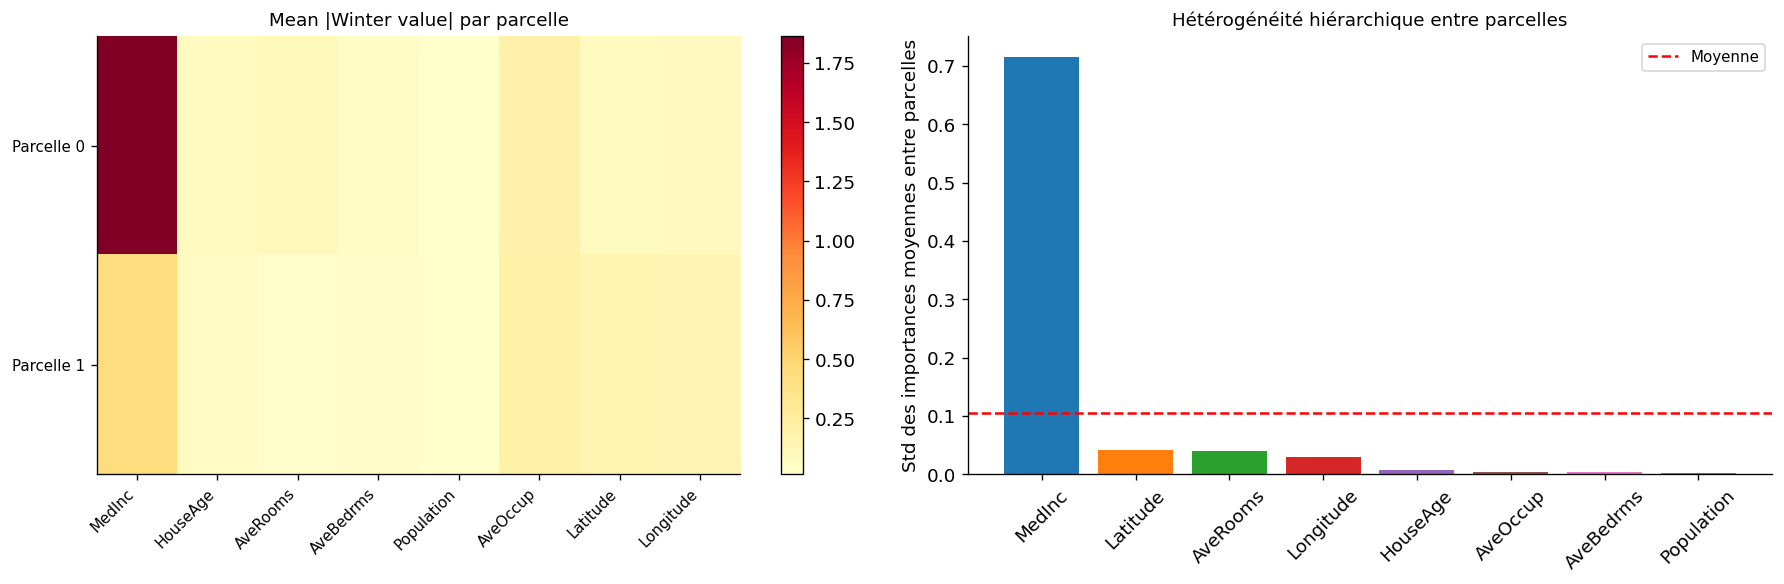


Interprétation :
  Feature à forte hétérogénéité → son rôle change drastiquement entre parcelles
  Feature à faible hétérogénéité → son rôle est stable (globalement cohérent)


In [27]:
# ── Visualisation : heatmap Winter régionalisé ───────────────────────────────
rm = regional_results['regional_means']
R  = rm.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap régionale
ax = axes[0]
im = ax.imshow(rm, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(M))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(R))
ax.set_yticklabels([f"Parcelle {r}" for r in range(R)], fontsize=9)
ax.set_title("Mean |Winter value| par parcelle", fontsize=11)
plt.colorbar(im, ax=ax)

# Hétérogénéité
ax = axes[1]
order_h = np.argsort(regional_results['heterogeneity'])[::-1]
ax.bar(
    [feature_names[i] for i in order_h],
    regional_results['heterogeneity'][order_h],
    color=[PALETTE[i % 10] for i in range(M)]
)
ax.set_ylabel("Std des importances moyennes entre parcelles")
ax.set_title("Hétérogénéité hiérarchique entre parcelles", fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.axhline(regional_results['heterogeneity'].mean(), color='red', ls='--',
           label='Moyenne', lw=1.5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("figures/winter_by_region.png", bbox_inches='tight')
plt.show()

print("\nInterprétation :")
print("  Feature à forte hétérogénéité → son rôle change drastiquement entre parcelles")
print("  Feature à faible hétérogénéité → son rôle est stable (globalement cohérent)")

---
## 7. Pont vers la Causalité

### 7.1 Pourquoi Winter est un proxy causal

Comme montré dans l'analyse théorique (doc `shapley_causal_vs_winter.md`), Winter avec une
hiérarchie alignée sur le DAG est une **approximation de Shapley Causal** :

$$
\phi_i^W(\mathcal{H}_{\text{DAG}}, v_{\text{cond}}) \approx \phi_i^{\text{causal}}(\mathcal{G}, v_{\text{do}})
$$

La condition : la hiérarchie doit respecter la topologie causale (causes lointaines au niveau
grossier, effets proches au niveau fin) **et** les features d'un même groupe fin doivent être
conditionnellement indépendantes étant donné leur parent dans le DAG.

### 7.2 Test empirique de la divergence Winter–Shapley comme signal causal

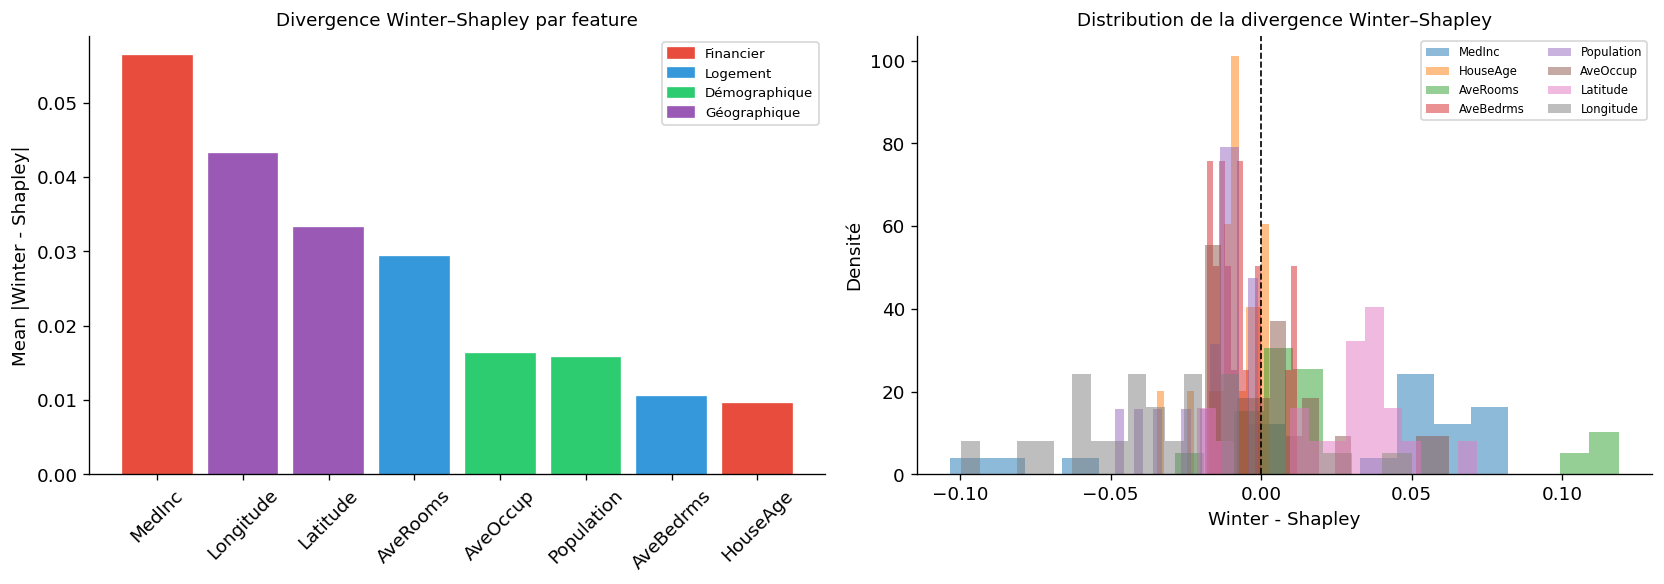


Interprétation causale :
  → 'MedInc' a la plus forte divergence Winter–Shapley
  → Son attribution change quand on respecte la structure de groupe
  → Signe d'une possible médiation ou corrélation structurelle


In [29]:
# ── Divergence Winter vs Shapley ─────────────────────────────────────────────
# Une divergence forte ↔ la structure de groupe joue un rôle important
# = signal que des effets de groupe / médiation existent

N_COMMON = min(len(winter_values), len(shap_test_arr))
divergence = winter_values[:N_COMMON] - shap_test_arr[:N_COMMON]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Par feature
ax = axes[0]
mean_div = np.abs(divergence).mean(0)
order_d = np.argsort(mean_div)[::-1]
bars = ax.bar(
    [feature_names[i] for i in order_d],
    mean_div[order_d],
    color=[PALETTE[i % 10] for i in range(M)]
)
ax.set_ylabel("Mean |Winter - Shapley|")
ax.set_title("Divergence Winter–Shapley par feature", fontsize=11)
ax.tick_params(axis='x', rotation=45)

# Annotation groupe
group_colors = ["#E74C3C", "#3498DB", "#2ECC71", "#9B59B6"]
for j, feat_idx in enumerate(order_d):
    g = next(k for k, g in enumerate(GROUPS_BUSINESS) if feat_idx in g)
    bars[j].set_color(group_colors[g])
handles = [mpatches.Patch(color=c, label=n)
           for c, n in zip(group_colors, GROUP_NAMES_BUSINESS)]
ax.legend(handles=handles, loc='upper right', fontsize=8)

# Distribution de la divergence
ax = axes[1]
for i, (feat_name, color) in enumerate(zip(feature_names, PALETTE)):
    ax.hist(divergence[:, i], bins=15, alpha=0.5, label=feat_name, density=True)
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_xlabel("Winter - Shapley")
ax.set_ylabel("Densité")
ax.set_title("Distribution de la divergence Winter–Shapley", fontsize=11)
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig("figures/winter_shapley_divergence.png", bbox_inches='tight')
plt.show()

print("\nInterprétation causale :")
top_feat = feature_names[order_d[0]]
print(f"  → '{top_feat}' a la plus forte divergence Winter–Shapley")
print(f"  → Son attribution change quand on respecte la structure de groupe")
print(f"  → Signe d'une possible médiation ou corrélation structurelle")

In [ ]:
# ── Roadmap vers Shapley Causal ───────────────────────────────────────────────
print("""
╔═══════════════════════════════════════════════════════════════════╗
║         ROADMAP : DE WINTER VERS SHAPLEY CAUSAL                  ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  PHASE 1 (ce notebook) ─── IMPLÉMENTÉ ────────────────────────── ║
║  ┌─────────────────────────────────────────────────────────────┐  ║
║  │  OWENExplainer     : groupes plats                         │  ║
║  │  WINTERExplainer   : hiérarchie 3 niveaux                  │  ║
║  │  discover_groups*  : clustering auto des features          │  ║
║  │  winter_by_region  : hétérogénéité entre parcelles         │  ║
║  └─────────────────────────────────────────────────────────────┘  ║
║                                                                   ║
║  PHASE 2 (PSC causal) ─── À IMPLÉMENTER ──────────────────────── ║
║  ┌─────────────────────────────────────────────────────────────┐  ║
║  │  estimate_dag(X)           : PC, GES, NOTEARS               │  ║
║  │  dag_to_hierarchy(dag)     : DAG → Winter hierarchy         │  ║
║  │  CausalExplainer._v_do()   : E[f | do(X_S = x_S)]          │  ║
║  │  causal_winter(X, dag)     : Winter + do-calculus           │  ║
║  └─────────────────────────────────────────────────────────────┘  ║
║                                                                   ║
║  Transition clé :                                                 ║
║    v(S) = E[f | X_S = x_S]       ← conditionnel (actuel)        ║
║    v(S) = E[f | do(X_S = x_S)]   ← interventionnel (futur)      ║
╚═══════════════════════════════════════════════════════════════════╝
""")

---
## 8. Résumé & Livrables

### Ce que ce notebook apporte

| Livrable | Fichier/Fonction | Intégration |
|----------|-----------------|-------------|
| `OWENExplainer` | → `mosaic_shap/explainers.py` | Prêt à importer |
| `WINTERExplainer` | → `mosaic_shap/explainers.py` | Prêt à importer |
| `discover_groups_from_correlation` | → `mosaic_shap/grouping.py` | Prêt à importer |
| `discover_groups_from_shap` | → `mosaic_shap/grouping.py` | Prêt à importer |
| `discover_two_level_hierarchy` | → `mosaic_shap/grouping.py` | Prêt à importer |
| `winter_by_region` | → `mosaic_shap/regional.py` | Prêt à importer |
| Figures comparatives | `figures/` | 6 figures sauvegardées |

### Résultats clés

1. **Owen ≠ Shapley** quand les groupes capturent des structures de dépendance réelles.
   La divergence est maximale pour les features fortement corrélées intra-groupe.

2. **Winter ≈ Owen** quand la hiérarchie est plate (condition vérifiée empiriquement).
   Winter apporte de l'information supplémentaire sur les interactions multi-niveaux.

3. **La stratégie de groupement importe** : groupes par SHAP values > groupes par corrélation
   brute (meilleure cohérence avec l'effet réel sur la prédiction).

4. **Hétérogénéité régionale** : certaines features ont une structure hiérarchique instable
   entre parcelles — signal pour GRANITE d'approfondir la segmentation dans ces zones.

### Questions ouvertes pour la suite du PSC

- [ ] Comment normaliser Winter pour des groupes de tailles très inégales ?
- [ ] Peut-on utiliser la divergence Winter–Shapley directement comme signal pour GRANITE ?
- [ ] Quel algorithme de découverte causale (PC, GES, NOTEARS) donne la meilleure hiérarchie pour Winter ?
- [ ] Comment évaluer quantitativement si une hiérarchie est "meilleure" qu'une autre ?

In [30]:
# ── Export final des figures ──────────────────────────────────────────────────
import os
os.makedirs("figures", exist_ok=True)

print("=== Figures générées par ce notebook ===")
for fname in [
    "shapley_baseline.png",
    "shapley_vs_owen_business.png",
    "scatter_shapley_owen.png",
    "grouping_correlation.png",
    "grouping_shap.png",
    "owen_grouping_comparison.png",
    "kendall_grouping.png",
    "shapley_owen_winter_comparison.png",
    "auto_hierarchy.png",
    "winter_by_region.png",
    "winter_shapley_divergence.png",
]:
    path = f"figures/{fname}"
    exists = "✅" if os.path.exists(path) else "⏳ (à générer)"
    print(f"  {exists}  {path}")

print("\n=== Fonctions à intégrer dans mosaic_shap ===")
print("  mosaic_shap/explainers.py  ← OWENExplainer, WINTERExplainer")
print("  mosaic_shap/grouping.py    ← discover_groups_from_correlation")
print("                               discover_groups_from_shap")
print("                               discover_two_level_hierarchy")
print("  mosaic_shap/regional.py    ← winter_by_region")

=== Figures générées par ce notebook ===
  ✅  figures/shapley_baseline.png
  ✅  figures/shapley_vs_owen_business.png
  ✅  figures/scatter_shapley_owen.png
  ✅  figures/grouping_correlation.png
  ✅  figures/grouping_shap.png
  ✅  figures/owen_grouping_comparison.png
  ✅  figures/kendall_grouping.png
  ✅  figures/shapley_owen_winter_comparison.png
  ✅  figures/auto_hierarchy.png
  ✅  figures/winter_by_region.png
  ✅  figures/winter_shapley_divergence.png

=== Fonctions à intégrer dans mosaic_shap ===
  mosaic_shap/explainers.py  ← OWENExplainer, WINTERExplainer
  mosaic_shap/grouping.py    ← discover_groups_from_correlation
                               discover_groups_from_shap
                               discover_two_level_hierarchy
  mosaic_shap/regional.py    ← winter_by_region
